# Análisis Cluster - Fórmula 1

En este notebook se realiza el **Análisis Cluster** del trabajo práctico.

Se comparan dos enfoques, como pidió el profesor:

1. **Clustering sin PCA:** se trabaja directamente con las variables numéricas seleccionadas del `df_model`, luego de escalarlas.
2. **Clustering con PCA:** se trabaja con la matriz de componentes principales guardada en el notebook anterior.

La idea no es solamente obtener etiquetas de cluster, sino también **comparar si los grupos cambian cuando se usa PCA** y describirlos en términos del problema: rendimiento posicional, vueltas completadas, edad del piloto y características del circuito.

## 1. Criterio general del análisis

El análisis cluster busca asignar observaciones a grupos tales que sean:

- **homogéneos internamente:** observaciones parecidas dentro del mismo grupo;
- **heterogéneos externamente:** observaciones diferentes entre grupos.

Para eso hay que tomar varias decisiones:

1. qué variables usar;
2. cómo medir cercanía entre observaciones;
3. qué algoritmo usar;
4. cómo elegir la cantidad de clusters;
5. cómo describir los grupos resultantes.

En este notebook se usa principalmente **distancia euclídea** sobre matrices numéricas. Para el caso sin PCA, las variables se escalan con **MinMaxScaler** para equilibrar su influencia en la distancia. Para el caso con PCA, se usan los scores de las componentes principales previamente guardados.

## 2. Importar librerías y definir rutas

In [1]:
# Para evitar que algunos cálculos de sklearn/numpy saturen la máquina local.
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics.pairwise import euclidean_distances

from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree, cophenet
from scipy.spatial.distance import squareform

try:
    from threadpoolctl import threadpool_limits
    threadpool_limits(1)
except Exception:
    pass

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [2]:
def encontrar_raiz_proyecto():
    """Busca hacia arriba una carpeta que contenga data/processed."""
    actual = Path.cwd().resolve()
    candidatos = [actual] + list(actual.parents)
    for carpeta in candidatos:
        if (carpeta / "data" / "processed").exists():
            return carpeta
    # Si no se encuentra, se asume que estamos en la raíz del proyecto.
    return actual

PROJECT_DIR = encontrar_raiz_proyecto()
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_DIR)
print("Carpeta processed:", PROCESSED_DIR)
print("Carpeta de figuras:", FIGURES_DIR)

Raíz del proyecto: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado
Carpeta processed: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed
Carpeta de figuras: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/reports/figures


## 3. Funciones auxiliares

Se definen funciones para:

- calcular la **Gap Statistic**;
- evaluar K-Means con método del codo, silhouette y Gap;
- graficar diagnósticos;
- aplicar clustering jerárquico en una muestra;
- resumir perfiles numéricos y categóricos de los clusters.

In [3]:
def calculate_gap_statistic(data, max_k=10, n_references=50, random_state=42):
    """
    Calcula la Gap Statistic para K-Means.

    Devuelve:
    - gaps: valores Gap(k)
    - s_k: desvío corregido
    - optimal_k: menor k que cumple Gap(k) >= Gap(k+1) - s(k+1)

    Para datasets medianos/grandes conviene aplicarla sobre una muestra.
    """
    if hasattr(data, "values"):
        data = data.values

    rng = np.random.default_rng(random_state)
    ks = range(1, max_k + 1)
    gaps = np.zeros(max_k)
    s_k = np.zeros(max_k)

    mins = data.min(axis=0)
    maxs = data.max(axis=0)

    for idx, k in enumerate(ks):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        km.fit(data)
        log_w = np.log(km.inertia_) if km.inertia_ > 0 else 0

        log_w_refs = np.zeros(n_references)
        for b in range(n_references):
            random_data = rng.random(size=data.shape) * (maxs - mins) + mins
            km_ref = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            km_ref.fit(random_data)
            log_w_refs[b] = np.log(km_ref.inertia_) if km_ref.inertia_ > 0 else 0

        gaps[idx] = np.mean(log_w_refs) - log_w
        s_k[idx] = np.std(log_w_refs, ddof=0) * np.sqrt(1 + 1.0 / n_references)

    optimal_k = max_k
    for i in range(len(ks) - 1):
        if gaps[i] >= gaps[i + 1] - s_k[i + 1]:
            optimal_k = i + 1
            break

    return gaps, s_k, optimal_k


def evaluar_kmeans(X, k_min=2, k_max=10, sample_size=1500, random_state=42, n_references_gap=50):
    """
    Evalúa K-Means para varios k.

    Se ajusta K-Means sobre una muestra para que el notebook sea liviano.
    Luego el modelo final se ajusta sobre todos los datos.
    """
    X = np.asarray(X)
    n = X.shape[0]

    if sample_size is not None and n > sample_size:
        rng = np.random.default_rng(random_state)
        idx_eval = rng.choice(n, size=sample_size, replace=False)
        X_eval = X[idx_eval]
    else:
        idx_eval = np.arange(n)
        X_eval = X

    ks = list(range(k_min, k_max + 1))
    inercias = []
    silhouettes = []
    min_cluster_prop = []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = km.fit_predict(X_eval)
        inercias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_eval, labels, metric="euclidean"))
        counts = np.bincount(labels)
        min_cluster_prop.append(counts.min() / counts.sum())

    gaps, s_k, k_gap = calculate_gap_statistic(
        X_eval, max_k=k_max, n_references=n_references_gap, random_state=random_state
    )

    resultados = pd.DataFrame({
        "k": ks,
        "inercia": inercias,
        "silhouette": silhouettes,
        "proporcion_cluster_mas_chico": min_cluster_prop,
        "gap": gaps[k_min-1:k_max],
        "gap_menos_s": (gaps - s_k)[k_min-1:k_max]
    })

    # Sugerencia: mejor silhouette entre soluciones sin clusters demasiado chicos.
    # El umbral evita elegir una partición sólo porque separa un micro-grupo de outliers.
    candidatas = resultados[resultados["proporcion_cluster_mas_chico"] >= 0.03]
    if len(candidatas) > 0:
        k_sugerido = int(candidatas.sort_values("silhouette", ascending=False).iloc[0]["k"])
    else:
        k_sugerido = int(resultados.sort_values("silhouette", ascending=False).iloc[0]["k"])

    resumen = {
        "k_silhouette_sugerido": k_sugerido,
        "k_gap": int(k_gap),
        "n_eval": X_eval.shape[0],
        "idx_eval": idx_eval
    }

    return resultados, resumen


def plot_diagnosticos_kmeans(resultados, titulo, guardar_como=None):
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    axs[0].plot(resultados["k"], resultados["inercia"], marker="o")
    axs[0].set_title("Método del codo")
    axs[0].set_xlabel("Número de clusters")
    axs[0].set_ylabel("WCSS / inercia")

    axs[1].plot(resultados["k"], resultados["silhouette"], marker="o")
    axs[1].set_title("Silhouette score")
    axs[1].set_xlabel("Número de clusters")
    axs[1].set_ylabel("Silhouette")

    axs[2].plot(resultados["k"], resultados["gap"], marker="o", label="Gap")
    axs[2].scatter(resultados["k"], resultados["gap_menos_s"], marker="x", label="Gap - s(k)")
    axs[2].set_title("Gap Statistic")
    axs[2].set_xlabel("Número de clusters")
    axs[2].set_ylabel("Gap")
    axs[2].legend()

    fig.suptitle(titulo, y=1.05, fontsize=14)
    plt.tight_layout()

    if guardar_como is not None:
        plt.savefig(FIGURES_DIR / guardar_como, dpi=150, bbox_inches="tight")

    plt.show()


def ajustar_kmeans_final(X, k, nombre_cluster, random_state=42):
    km = KMeans(n_clusters=k, random_state=random_state, n_init=50)
    labels = km.fit_predict(X)
    print(f"Tamaño de clusters para {nombre_cluster}:")
    display(pd.Series(labels).value_counts().sort_index().rename("n").to_frame())
    return km, labels


def analisis_jerarquico_muestra(X, k_final, titulo, sample_size=800, random_state=42, guardar_como=None):
    """
    Replica la lógica de la práctica: distancias euclídeas, dendrogramas,
    silhouette por encadenamiento y coeficiente cofenético.

    Se trabaja sobre una muestra para evitar problemas de memoria y para que
    el dendrograma sea legible.
    """
    X = np.asarray(X)
    n = X.shape[0]
    rng = np.random.default_rng(random_state)

    if n > sample_size:
        idx = rng.choice(n, size=sample_size, replace=False)
        X_sample = X[idx]
    else:
        idx = np.arange(n)
        X_sample = X

    D = euclidean_distances(X_sample, X_sample)
    condensed_D = squareform(D, checks=False)

    Zs = {
        "simple": linkage(condensed_D, method="single"),
        "completo": linkage(condensed_D, method="complete"),
        "promedio": linkage(condensed_D, method="average"),
        "ward": linkage(condensed_D, method="ward")
    }

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (nombre, Z) in zip(axs.ravel(), Zs.items()):
        dendrogram(Z, ax=ax, no_labels=True, color_threshold=None)
        ax.set_title(f"Encadenamiento {nombre}")
        ax.set_xlabel("Observaciones de la muestra")
        ax.set_ylabel("Altura")
    fig.suptitle(titulo, y=1.02)
    plt.tight_layout()

    if guardar_como is not None:
        plt.savefig(FIGURES_DIR / guardar_como, dpi=150, bbox_inches="tight")

    plt.show()

    k_range = range(2, 11)
    sil_rows = []
    for nombre, Z in Zs.items():
        for k in k_range:
            labels = cut_tree(Z, n_clusters=k).reshape(-1)
            sil = silhouette_score(D, labels, metric="precomputed")
            sil_rows.append({"encadenamiento": nombre, "k": k, "silhouette": sil})
    sil_df = pd.DataFrame(sil_rows)

    plt.figure(figsize=(9, 5))
    sns.lineplot(data=sil_df, x="k", y="silhouette", hue="encadenamiento", marker="o")
    plt.title(f"Silhouette por encadenamiento - {titulo}")
    plt.xlabel("Número de clusters")
    plt.ylabel("Silhouette")
    plt.tight_layout()
    plt.show()

    ccc = []
    for nombre, Z in Zs.items():
        valor, _ = cophenet(Z, condensed_D)
        ccc.append({"encadenamiento": nombre, "coeficiente_cofenetico": valor})
    ccc_df = pd.DataFrame(ccc).sort_values("coeficiente_cofenetico", ascending=False)

    labels_ward = cut_tree(Zs["ward"], n_clusters=k_final).reshape(-1)
    print(f"Tamaño de clusters Ward en muestra, k={k_final}:")
    display(pd.Series(labels_ward).value_counts().sort_index().rename("n").to_frame())

    return {
        "idx_muestra": idx,
        "D": D,
        "Zs": Zs,
        "silhouette": sil_df,
        "cofenetico": ccc_df,
        "labels_ward_muestra": labels_ward
    }


def perfil_numerico(df, cluster_col, variables):
    resumen = (
        df.groupby(cluster_col)[variables]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(3)
    )
    return resumen


def perfil_categorico(df, cluster_col, variable_cat):
    tabla = pd.crosstab(df[cluster_col], df[variable_cat], normalize="index").round(3)
    return tabla


def plot_boxplots_clusters(df, cluster_col, variables, titulo, guardar_como=None):
    n_vars = len(variables)
    n_cols = 3
    n_rows = int(np.ceil(n_vars / n_cols))
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axs = np.array(axs).reshape(-1)

    for ax, var in zip(axs, variables):
        sns.boxplot(data=df, x=cluster_col, y=var, hue=cluster_col, legend=False, ax=ax)
        ax.set_title(var)
        ax.set_xlabel("Cluster")
    for ax in axs[len(variables):]:
        ax.axis("off")

    fig.suptitle(titulo, y=1.02)
    plt.tight_layout()

    if guardar_como is not None:
        plt.savefig(FIGURES_DIR / guardar_como, dpi=150, bbox_inches="tight")

    plt.show()


def plot_categorica_fill(df, cluster_col, variable_cat, titulo, guardar_como=None):
    tabla = pd.crosstab(df[cluster_col], df[variable_cat], normalize="index")
    ax = tabla.plot(kind="bar", stacked=True, figsize=(10, 5))
    ax.set_title(titulo)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Proporción")
    ax.legend(title=variable_cat, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if guardar_como is not None:
        plt.savefig(FIGURES_DIR / guardar_como, dpi=150, bbox_inches="tight")

    plt.show()

## 4. Cargar `df_model`

Se intenta usar el `df_model` que ya exista en memoria. Si no existe, se carga la base procesada generada en el EDA.

In [4]:
try:
    df_model
    print("Se usa df_model existente en memoria.")
except NameError:
    ruta_base = PROCESSED_DIR / "formula1_base_trabajo.csv"
    if not ruta_base.exists():
        raise FileNotFoundError(
            "No existe df_model en memoria ni se encontró data/processed/formula1_base_trabajo.csv. "
            "Primero corré el notebook de EDA."
        )
    df_model = pd.read_csv(ruta_base)
    print("Se cargó df_model desde:", ruta_base)

print("Dimensiones de df_model:", df_model.shape)
display(df_model.head())

Se cargó df_model desde: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_base_trabajo.csv
Dimensiones de df_model: (10000, 43)


,year,decada,round,race_name,race_date,circuit_name,circuit_country,circuit_location,driver_name,driver_nationality,driver_age,constructor_name,constructor_nationality,grid,largada_grupo,positionOrder,resultado_grupo,race_points,laps,status,status_grupo,driver_championship_points,driver_championship_position,driver_championship_wins,resultId,raceId,driverId,constructorId,statusId,circuitId,driverRef,dob,constructorRef,circuitRef,circuit_lat,circuit_lng,circuit_alt,podio,top10,victoria,laps_max_race,laps_pct,vueltas_perdidas
0,2024,2020s,12,British Grand Prix,2024-07-07,Silverstone Circuit,UK,Silverstone,Oscar Piastri,Australian,23.252567,McLaren,British,5,Top 5,4,Top 10,12.0,52,Finished,Clasificado / terminó,124.0,5.0,0.0,26508,1132,857,1,1,9,piastri,2001-04-06,mclaren,silverstone,52.07860,-1.01694,153,0,1,0,52,1.000000,0
1,2008,2000s,2,Malaysian Grand Prix,2008-03-23,Sepang International Circuit,Malaysia,Kuala Lumpur,Giancarlo Fisichella,Italian,35.186858,Force India,Indian,17,Fondo,12,Fuera del top 10,0.0,55,+1 Lap,Clasificado / terminó,0.0,15.0,0.0,34,19,21,10,11,2,fisichella,1973-01-14,force_india,sepang,2.76083,101.73800,18,0,0,0,56,0.982143,1
2,2005,2000s,12,German Grand Prix,2005-07-24,Hockenheimring,Germany,Hockenheim,Narain Karthikeyan,Indian,28.522930,Jordan,Irish,19,Fondo,16,Fuera del top 10,0.0,64,+3 Laps,Clasificado / terminó,5.0,17.0,0.0,1370,82,39,17,13,10,karthikeyan,1977-01-14,jordan,hockenheimring,49.32780,8.56583,103,0,0,0,67,0.955224,3
3,2009,2000s,16,Brazilian Grand Prix,2009-10-18,Autódromo José Carlos Pace,Brazil,São Paulo,Adrian Sutil,German,26.767967,Force India,Indian,3,Top 5,18,Fuera del top 10,0.0,0,Accident,Incidente / abandono,5.0,16.0,0.0,7871,16,16,10,3,18,sutil,1983-01-11,force_india,interlagos,-23.70360,-46.69970,785,0,0,0,71,0.000000,71
4,2000,2000s,16,Japanese Grand Prix,2000-10-08,Suzuka Circuit,Japan,Suzuka,Giancarlo Fisichella,Italian,27.731691,Benetton,Italian,12,Fondo,14,Fuera del top 10,0.0,52,+1 Lap,Clasificado / terminó,18.0,6.0,0.0,3273,173,21,22,11,22,fisichella,1973-01-14,benetton,suzuka,34.84310,136.54100,45,0,0,0,53,0.981132,1


In [5]:
# ============================================================
# Variable derivada: proporción de vueltas completadas
# ============================================================

# Si laps_pct no existe, la creamos a partir de laps y raceId.
# Esto asegura que el notebook de clustering funcione aunque se cargue
# una versión de la base que todavía no tenga la variable guardada.

if "laps_pct" not in df_model.columns:

    if "raceId" not in df_model.columns:
        raise ValueError("No se puede calcular laps_pct porque df_model no tiene la columna raceId.")

    if "laps" not in df_model.columns:
        raise ValueError("No se puede calcular laps_pct porque df_model no tiene la columna laps.")

    df_model["laps_max_race"] = df_model.groupby("raceId")["laps"].transform("max")
    df_model["laps_pct"] = df_model["laps"] / df_model["laps_max_race"]
    df_model["vueltas_perdidas"] = df_model["laps_max_race"] - df_model["laps"]

print(df_model[["raceId", "laps", "laps_max_race", "laps_pct", "vueltas_perdidas"]].head())

   raceId  laps  laps_max_race  laps_pct  vueltas_perdidas
0    1132    52             52  1.000000                 0
1      19    55             56  0.982143                 1
2      82    64             67  0.955224                 3
3      16     0             71  0.000000                71
4     173    52             53  0.981132                 1


## 5. Selección de variables para clustering sin PCA

Para que la comparación sea justa, el clustering sin PCA usa las mismas variables numéricas que fueron consideradas para el PCA, pero **sin transformar a componentes principales**.

Se excluyen los puntos (`race_points` y `driver_championship_points`) porque el sistema de puntuación de Fórmula 1 cambió históricamente y los puntos brutos no son totalmente comparables entre temporadas.

También se evita incluir variables binarias derivadas como `podio`, `top10` o `victoria`, porque duplican información contenida en `positionOrder`.

In [6]:
variables_cluster_base = [
    "grid",
    "positionOrder",
    "laps_pct",
    "driver_age",
    "driver_championship_position",
    "driver_championship_wins"
]

variables_faltantes = [v for v in variables_cluster_base if v not in df_model.columns]
if variables_faltantes:
    raise ValueError(f"Faltan variables en df_model: {variables_faltantes}")

# Copia de trabajo para clustering.
df_cluster = df_model.copy()

# Variable derivada útil para interpretar, pero no se usa como variable activa porque depende de grid y positionOrder.
df_cluster["posiciones_ganadas"] = df_cluster["grid"] - df_cluster["positionOrder"]

# Se eliminan observaciones con NA en las variables activas.
df_cluster = df_cluster.dropna(subset=variables_cluster_base).reset_index(drop=True)

print("Observaciones disponibles para clustering:", df_cluster.shape[0])
print("Variables activas sin PCA:")
print(variables_cluster_base)

display(df_cluster[variables_cluster_base].describe().T.round(3))

Observaciones disponibles para clustering: 9847
Variables activas sin PCA:
['grid', 'positionOrder', 'laps_pct', 'driver_age', 'driver_championship_position', 'driver_championship_wins']


,count,mean,std,min,25%,50%,75%,max
grid,9847.0,10.856,6.178,0.000,6.000,11.000,16.00,24.000
positionOrder,9847.0,10.969,6.143,1.000,6.000,11.000,16.00,24.000
laps_pct,9847.0,0.867,0.281,0.000,0.964,0.986,1.00,1.000
driver_age,9847.0,28.270,5.017,17.454,24.371,27.504,31.57,43.893
driver_championship_position,9847.0,11.164,6.368,1.000,6.000,11.000,16.00,27.000
driver_championship_wins,9847.0,0.492,1.516,0.000,0.000,0.000,0.00,19.000


## 6. Matriz sin PCA: escalado Min-Max

Como las variables están en escalas distintas, se aplica Min-Max:

\[
$X' = \frac{X - \min(X)}{\max(X) - \min(X)}$
\]

Esto lleva cada variable al rango \([0, 1]\), de modo que ninguna domine la distancia euclídea solo por su unidad de medida.

In [7]:
scaler_minmax = MinMaxScaler()
X_sin_pca = scaler_minmax.fit_transform(df_cluster[variables_cluster_base])

X_sin_pca_df = pd.DataFrame(X_sin_pca, columns=variables_cluster_base)
X_sin_pca_df.to_csv(PROCESSED_DIR / "formula1_cluster_matriz_sin_pca_minmax.csv", index=False)

print("Matriz sin PCA escalada:", X_sin_pca_df.shape)
display(X_sin_pca_df.head())

Matriz sin PCA escalada: (9847, 6)


,grid,positionOrder,laps_pct,driver_age,driver_championship_position,driver_championship_wins
0,0.208333,0.130435,1.000000,0.219323,0.153846,0.0
1,0.708333,0.478261,0.982143,0.670705,0.538462,0.0
2,0.791667,0.652174,0.955224,0.418660,0.615385,0.0
3,0.125000,0.739130,0.000000,0.352283,0.576923,0.0
4,0.500000,0.565217,0.981132,0.388734,0.192308,0.0


## 7. Matriz con PCA

Se intenta cargar la matriz PCA generada en el notebook anterior:

`data/processed/formula1_pca_matriz_cluster_numerica.csv`

Esta matriz contiene los scores de **CP1 y CP2**, seleccionadas según la regla de Kaiser, ya que son las componentes con autovalor mayor a 1. Aunque incluir CP3 permitiría alcanzar aproximadamente el 80% de varianza acumulada, esa componente quedó asociada principalmente a la edad del piloto y no se utilizó para el clustering final.

Si la matriz guardada no existe o no coincide en cantidad de filas con la base actual, el PCA se recalcula dentro de este notebook usando el mismo criterio.

In [8]:
ruta_pca_cluster = PROCESSED_DIR / "formula1_pca_matriz_cluster_numerica.csv"
ruta_pca_scores = PROCESSED_DIR / "formula1_pca_scores_cluster.csv"

usar_pca_guardado = False

# Componentes finales decididas para clustering
componentes_finales = ["CP1", "CP2"]

if ruta_pca_cluster.exists():
    pca_guardado = pd.read_csv(ruta_pca_cluster)

    pc_cols_guardadas = [
        c for c in pca_guardado.columns
        if c.startswith("CP")
    ]

    if (
        len(pca_guardado) == len(df_cluster)
        and all(cp in pc_cols_guardadas for cp in componentes_finales)
    ):
        X_con_pca_df = pca_guardado[componentes_finales].copy()
        usar_pca_guardado = True
        print("Se usa la matriz PCA guardada:", ruta_pca_cluster)
    else:
        print("La matriz PCA guardada existe, pero no coincide con la base actual. Se recalcula el PCA.")
else:
    print("No se encontró matriz PCA guardada. Se recalcula el PCA.")


if not usar_pca_guardado:
    scaler_pca = StandardScaler()
    Z_para_pca = scaler_pca.fit_transform(df_cluster[variables_cluster_base])

    pca_cluster = PCA()
    scores_pca = pca_cluster.fit_transform(Z_para_pca)

    var_acum = np.cumsum(pca_cluster.explained_variance_ratio_)

    n_componentes_kaiser = int((pca_cluster.explained_variance_ > 1).sum())
    n_componentes_kaiser = max(n_componentes_kaiser, 2)

    # Decisión final del trabajo:
    # Se utilizan CP1 y CP2, siguiendo la regla de Kaiser y la interpretación del PCA.
    n_componentes_cluster = 2

    pc_cols_todas = [f"CP{i}" for i in range(1, scores_pca.shape[1] + 1)]
    pc_cols_cluster = componentes_finales

    scores_todas_df = pd.DataFrame(scores_pca, columns=pc_cols_todas)

    X_con_pca_df = scores_todas_df[pc_cols_cluster].copy()

    # Guardamos la matriz final usada para clustering
    X_con_pca_df.to_csv(ruta_pca_cluster, index=False)

    # Guardamos también todos los scores por si se quieren revisar después
    scores_todas_df.to_csv(ruta_pca_scores, index=False)

    varianza_cluster = pd.DataFrame({
        "componente": pc_cols_todas,
        "autovalor": pca_cluster.explained_variance_,
        "varianza_explicada": pca_cluster.explained_variance_ratio_,
        "varianza_acumulada": var_acum
    })

    varianza_cluster.to_csv(
        PROCESSED_DIR / "formula1_cluster_pca_varianza_usada.csv",
        index=False
    )

    print("Componentes sugeridas por Kaiser:", n_componentes_kaiser)
    print("Componentes elegidas para clustering:", n_componentes_cluster)
    print(
        "Varianza acumulada con CP1 y CP2:",
        f"{varianza_cluster.loc[n_componentes_cluster - 1, 'varianza_acumulada']:.2%}"
    )

    display(varianza_cluster.round(4))


X_con_pca = X_con_pca_df.values
pc_cols = list(X_con_pca_df.columns)

print("Matriz con PCA:", X_con_pca_df.shape)
display(X_con_pca_df.head())

La matriz PCA guardada existe, pero no coincide con la base actual. Se recalcula el PCA.
Componentes sugeridas por Kaiser: 2
Componentes elegidas para clustering: 2
Varianza acumulada con CP1 y CP2: 64.93%


,componente,autovalor,varianza_explicada,varianza_acumulada
0,CP1,2.7715,0.4619,0.4619
1,CP2,1.1246,0.1874,0.6493
2,CP3,0.9646,0.1608,0.8100
3,CP4,0.6834,0.1139,0.9239
4,CP5,0.2722,0.0454,0.9693
5,CP6,0.1843,0.0307,1.0000


Matriz con PCA: (9847, 2)


,CP1,CP2
0,-1.461853,0.672010
1,0.725022,0.325068
2,1.559985,0.615804
3,1.419123,-2.708912
4,-0.064552,0.148605


## 8. Clustering sin PCA

Primero se aplica K-Means sobre la matriz original escalada.

Se evalúa la cantidad de clusters con tres criterios:

- **Método del codo:** analiza la caída de la suma de cuadrados intra-cluster.
- **Silhouette:** mide separación y cohesión de los clusters.
- **Gap Statistic:** compara la inercia observada contra una referencia aleatoria.

> Importante: estos criterios no siempre coinciden. Por eso se usa una sugerencia automática, pero se deja explícito el valor final de `K_FINAL_SIN_PCA` para poder modificarlo después de mirar los gráficos.

,k,inercia,silhouette,proporcion_cluster_mas_chico,gap,gap_menos_s
0,2,297.3896,0.3360,0.4773,0.6533,0.6442
1,3,196.3047,0.3785,0.1467,0.9561,0.9454
2,4,167.5335,0.2867,0.1413,1.0205,1.0092
3,5,150.1881,0.2952,0.1380,1.0472,1.0368
4,6,137.0011,0.2835,0.0727,1.0685,1.0575
5,7,126.0833,0.2518,0.0680,1.0931,1.0836
6,8,118.5230,0.2303,0.0673,1.0991,1.0887
7,9,110.9425,0.2318,0.0547,1.1100,1.0988
8,10,105.2779,0.2259,0.0560,1.1126,1.1022


Resumen: {'k_silhouette_sugerido': 3, 'k_gap': 7, 'n_eval': 1500}


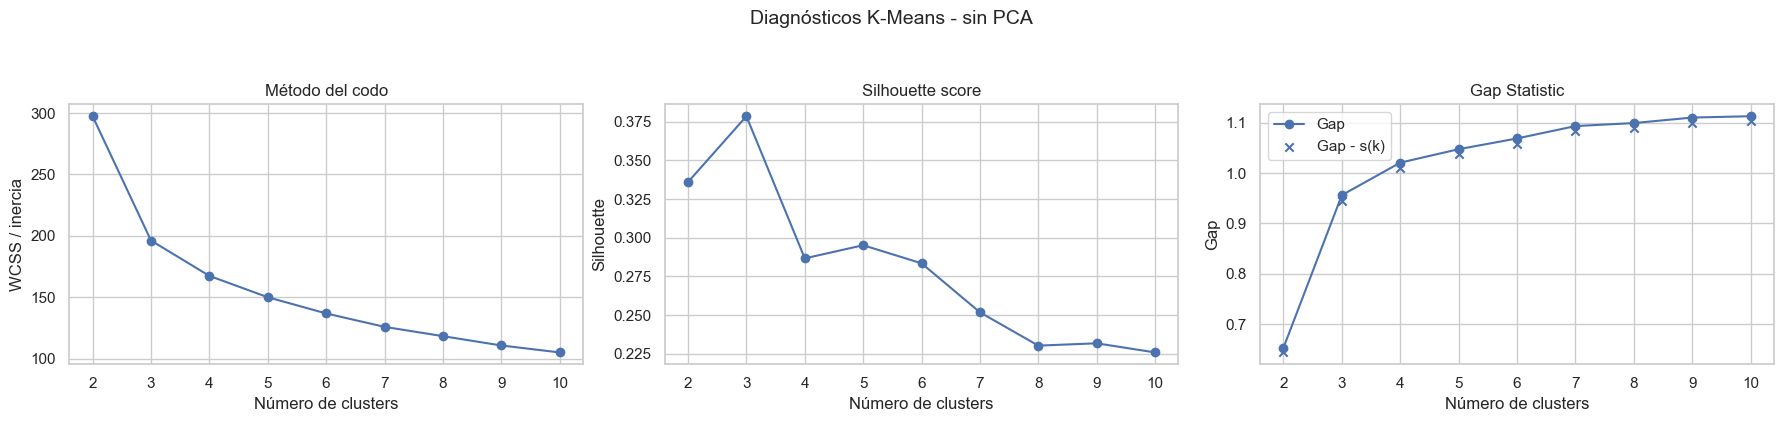

In [9]:
resultados_sin_pca, resumen_sin_pca = evaluar_kmeans(
    X_sin_pca,
    k_min=2,
    k_max=10,
    sample_size=1500,
    random_state=RANDOM_STATE,
    n_references_gap=50
)

display(resultados_sin_pca.round(4))
print("Resumen:", {k: v for k, v in resumen_sin_pca.items() if k != "idx_eval"})

plot_diagnosticos_kmeans(
    resultados_sin_pca,
    titulo="Diagnósticos K-Means - sin PCA",
    guardar_como="cluster_sin_pca_diagnosticos_kmeans.png"
)

In [10]:
# Ajustar si al mirar los gráficos se justifica otro valor.
K_FINAL_SIN_PCA = 3

print("K final elegido para clustering sin PCA:", K_FINAL_SIN_PCA)

kmeans_sin_pca, labels_sin_pca = ajustar_kmeans_final(
    X_sin_pca,
    k=K_FINAL_SIN_PCA,
    nombre_cluster="cluster_sin_pca",
    random_state=RANDOM_STATE
)

df_cluster["cluster_sin_pca"] = labels_sin_pca

K final elegido para clustering sin PCA: 3
Tamaño de clusters para cluster_sin_pca:


,n
0,1442
1,4154
2,4251


### 8.1. Clustering jerárquico sin PCA, sobre muestra

El algoritmo jerárquico exige calcular muchas distancias entre observaciones. Como el dataset tiene cerca de 10.000 filas, el dendrograma completo sería pesado y poco legible. Por eso se aplica el análisis jerárquico sobre una **muestra**.

Esto sirve para comparar la estructura aproximada con distintos encadenamientos: simple, completo, promedio y Ward.

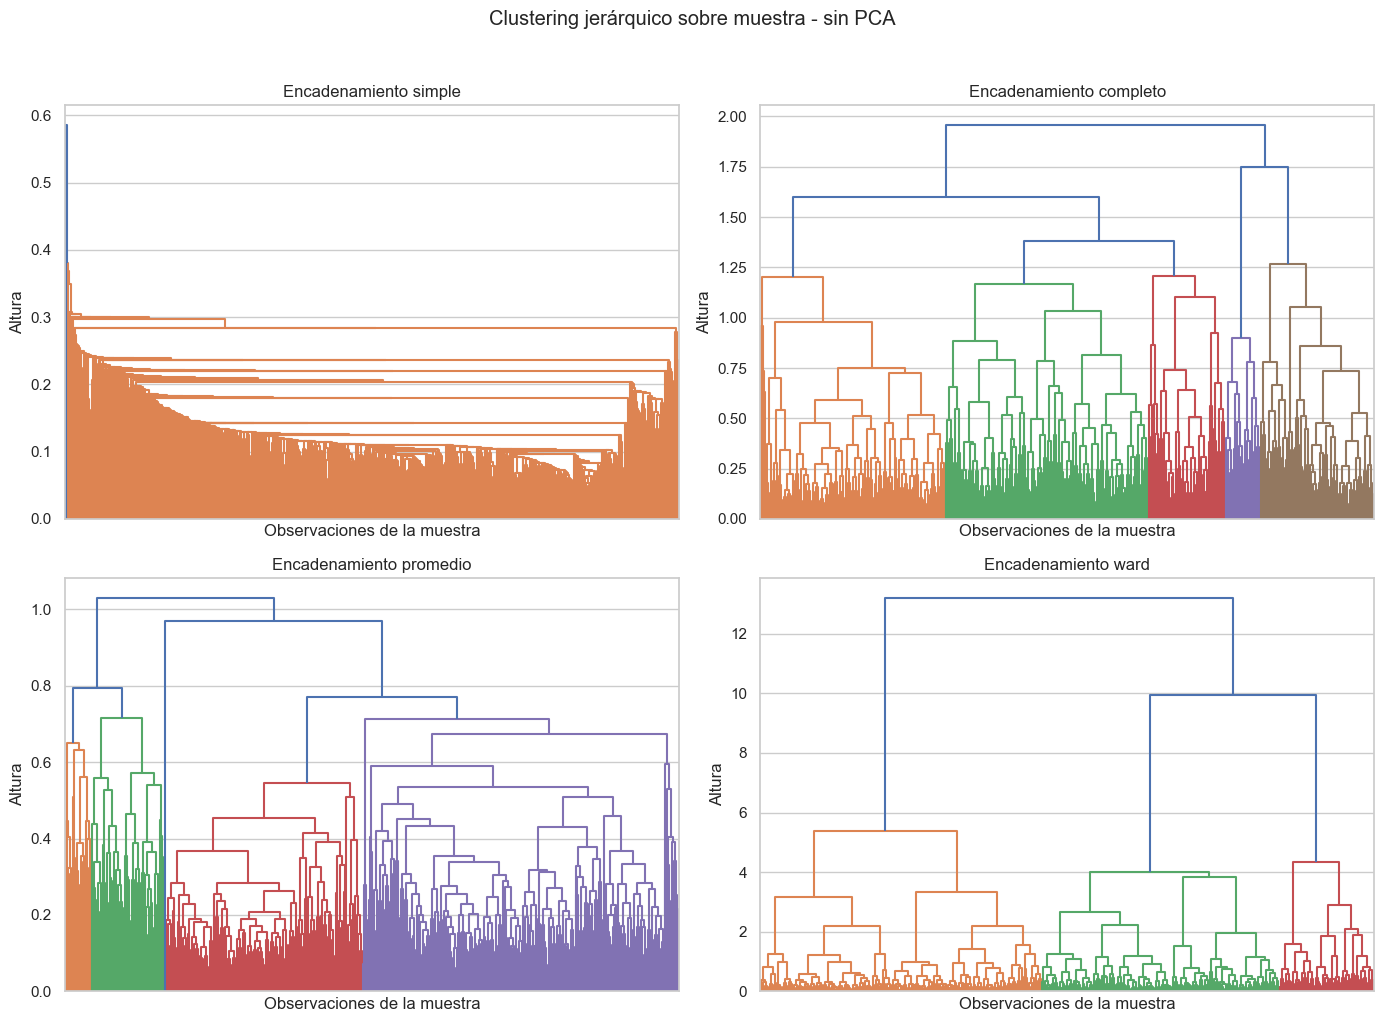

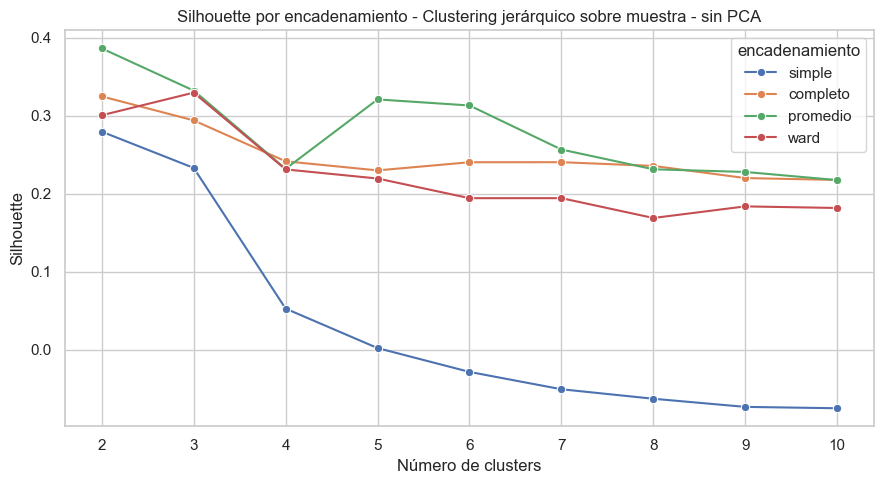

Tamaño de clusters Ward en muestra, k=3:


,n
0,310
1,367
2,123


Coeficientes cofenéticos:


,encadenamiento,coeficiente_cofenetico
2,promedio,0.7296
1,completo,0.6353
3,ward,0.5857
0,simple,0.4818


Silhouette por encadenamiento:


encadenamiento,completo,promedio,simple,ward
k,,,,
2,0.3247,0.3862,0.2795,0.3006
3,0.2940,0.3321,0.2331,0.3295
4,0.2416,0.2319,0.0529,0.2312
5,0.2299,0.3208,0.0024,0.2195
6,0.2404,0.3131,-0.0281,0.1944
7,0.2404,0.2566,-0.0503,0.1944
8,0.2357,0.2314,-0.0625,0.1690
9,0.2201,0.2279,-0.0729,0.1839
10,0.2177,0.2175,-0.0747,0.1818


In [11]:
jerarquico_sin_pca = analisis_jerarquico_muestra(
    X_sin_pca,
    k_final=K_FINAL_SIN_PCA,
    titulo="Clustering jerárquico sobre muestra - sin PCA",
    sample_size=800,
    random_state=RANDOM_STATE,
    guardar_como="cluster_sin_pca_dendrogramas_muestra.png"
)

print("Coeficientes cofenéticos:")
display(jerarquico_sin_pca["cofenetico"].round(4))

print("Silhouette por encadenamiento:")
display(jerarquico_sin_pca["silhouette"].pivot(index="k", columns="encadenamiento", values="silhouette").round(4))

## 9. Perfil de clusters sin PCA

Se describen los clusters usando:

- las variables numéricas activas;
- la variable derivada `posiciones_ganadas`;
- variables categóricas suplementarias como `resultado_grupo`, `largada_grupo`, `status_grupo` y `decada`.

In [12]:
variables_perfil_numericas = variables_cluster_base + ["posiciones_ganadas"]

perfil_sin_pca = perfil_numerico(df_cluster, "cluster_sin_pca", variables_perfil_numericas)
display(perfil_sin_pca)

perfil_sin_pca.to_csv(PROCESSED_DIR / "formula1_cluster_perfil_numerico_sin_pca.csv")

grid                               positionOrder                               laps_pct                              \
                count    mean median    std min max         count    mean median    std min max    count   mean median    std    min   
cluster_sin_pca                                                                                                                        
0                1442  11.966   12.0  5.939   0  24          1442  19.384   20.0  2.265   7  24     1442  0.234  0.197  0.211  0.000   
1                4154   5.844    5.0  3.782   0  24          4154   5.423    5.0  3.536   1  21     4154  0.993  1.000  0.038  0.511   
2                4251  15.378   16.0  4.131   0  24          4251  13.535   13.0  3.577   3  24     4251  0.958  0.983  0.078  0.507   

                      driver_age                                        driver_championship_position                                   \
                  max      count    mean  median    std     min     max                        count    mean median    std  min   max   
cluster_sin_pca                                                                                                                         
0                0.75       1442  28.147  27.546  5.016  17.454  43.721                         1442  13.205   13.0  5.989  1.0  27.0   
1                1.00       4154  29.032  28.705  4.902  17.492  43.682                         4154   5.744    5.0  3.513  1.0  19.0   
2                1.00       4251  27.568  26.453  5.025  17.530  43.893                         4251  15.769   16.0  4.289  2.0  27.0   

                driver_championship_wins                                 posiciones_ganadas                               
                                   count   mean median    std  min   max              count   mean median    std min max  
cluster_sin_pca                                                                                                           
0                                   1442  0.206    0.0  0.757  0.0  11.0               1442 -7.418   -7.0  6.060 -24   8  
1                                   4154  1.080    0.0  2.150  0.0  19.0               4154  0.421    0.0  4.386 -20  21  
2                                   4251  0.015    0.0  0.136  0.0   2.0               4251  1.843    2.0  4.833 -20  19

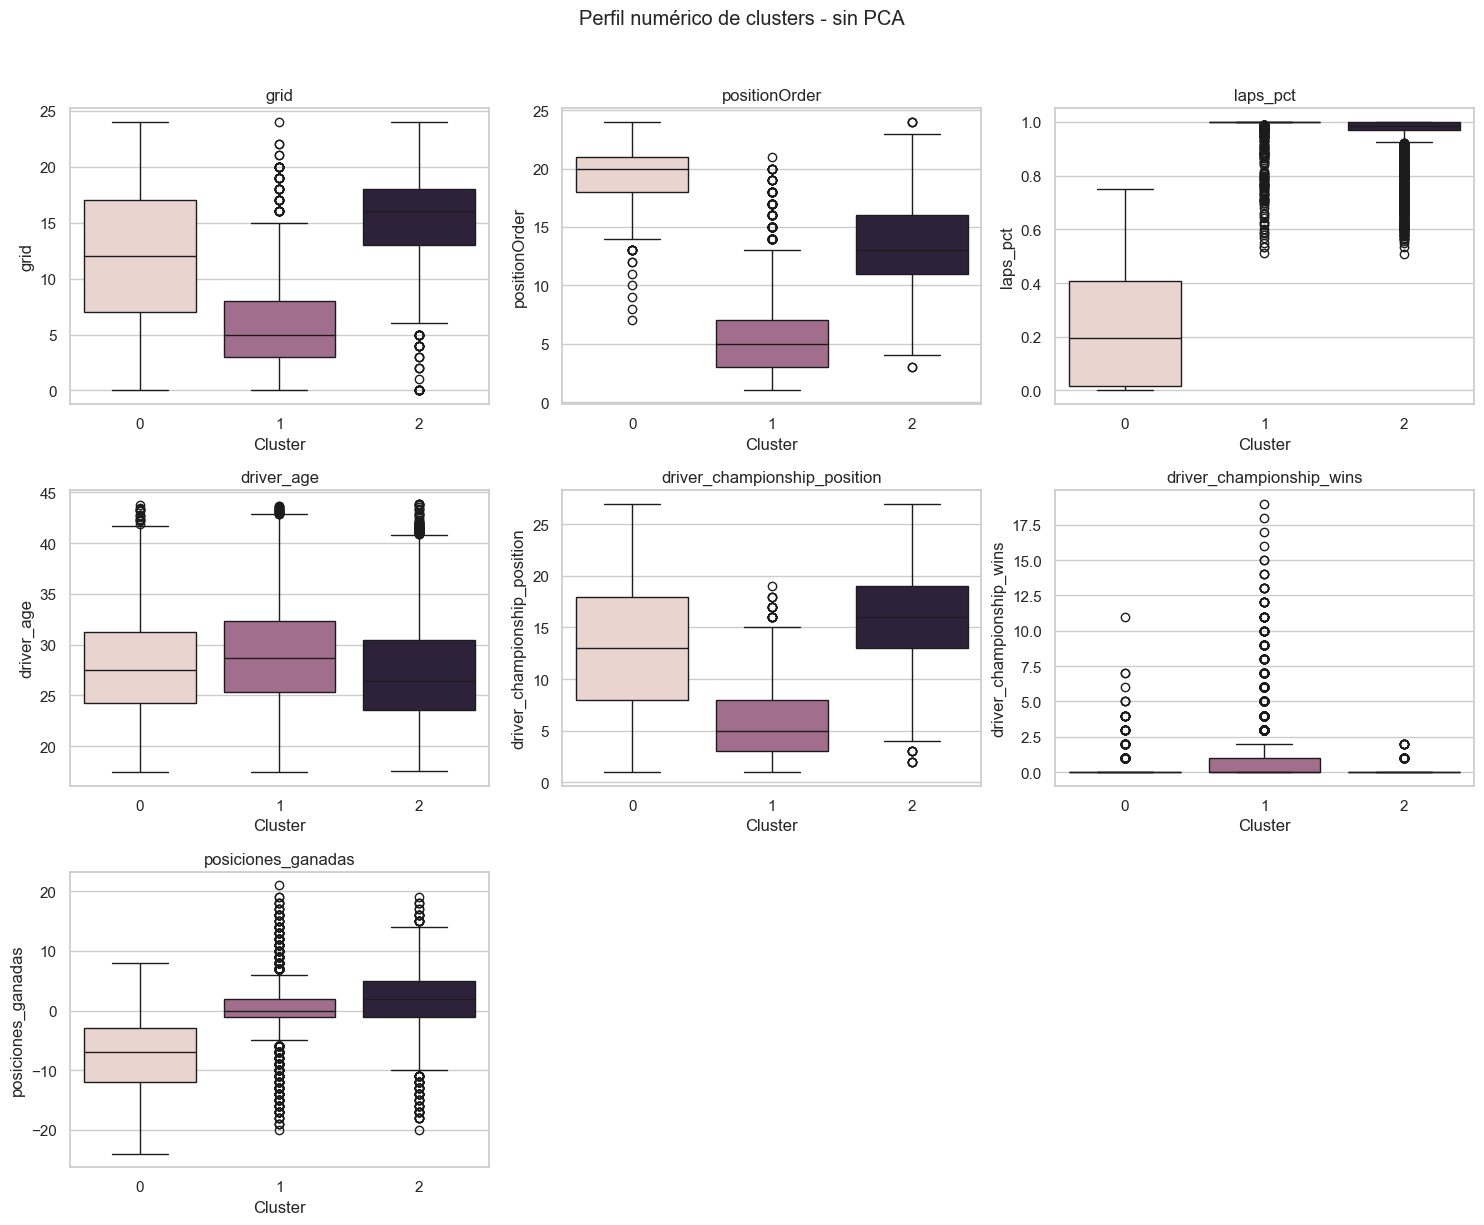

In [13]:
plot_boxplots_clusters(
    df_cluster,
    cluster_col="cluster_sin_pca",
    variables=variables_perfil_numericas,
    titulo="Perfil numérico de clusters - sin PCA",
    guardar_como="cluster_sin_pca_boxplots.png"
)


Distribución de resultado_grupo por cluster sin PCA


resultado_grupo,Fuera del top 10,Ganador,Podio,Top 10
cluster_sin_pca,,,,
0,0.997,0.000,0.000,0.003
1,0.077,0.115,0.229,0.579
2,0.786,0.000,0.000,0.213


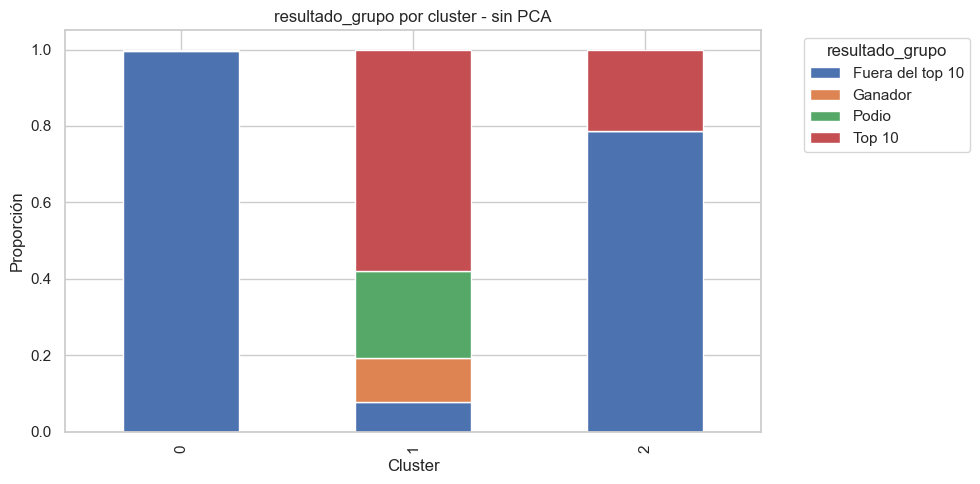


Distribución de largada_grupo por cluster sin PCA


largada_grupo,Fondo,Pit lane / no largó,Pole,Top 10,Top 5
cluster_sin_pca,,,,,
0,0.592,0.017,0.022,0.234,0.135
1,0.117,0.010,0.106,0.367,0.400
2,0.874,0.004,0.000,0.114,0.007


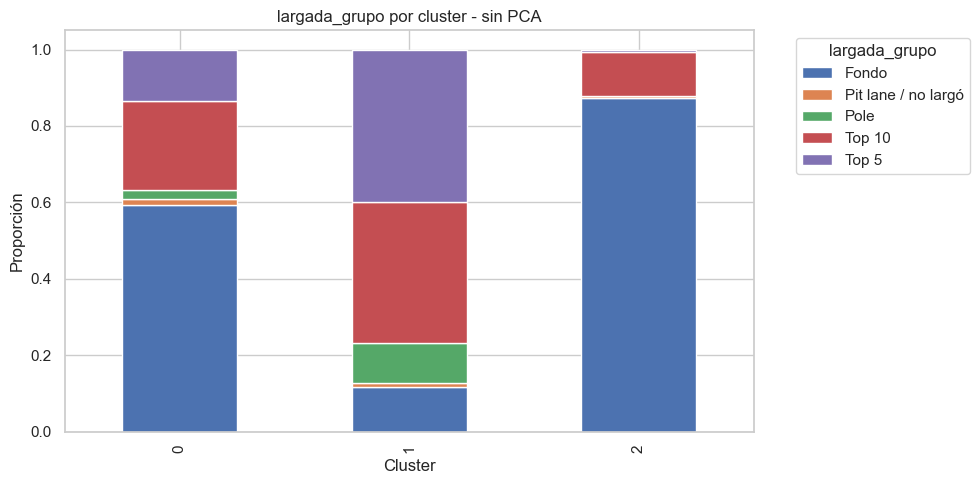


Distribución de status_grupo por cluster sin PCA


status_grupo,Abandono mecánico,Clasificado / terminó,Incidente / abandono,Otro
cluster_sin_pca,,,,
0,0.408,0.001,0.472,0.118
1,0.016,0.968,0.010,0.005
2,0.067,0.862,0.052,0.020


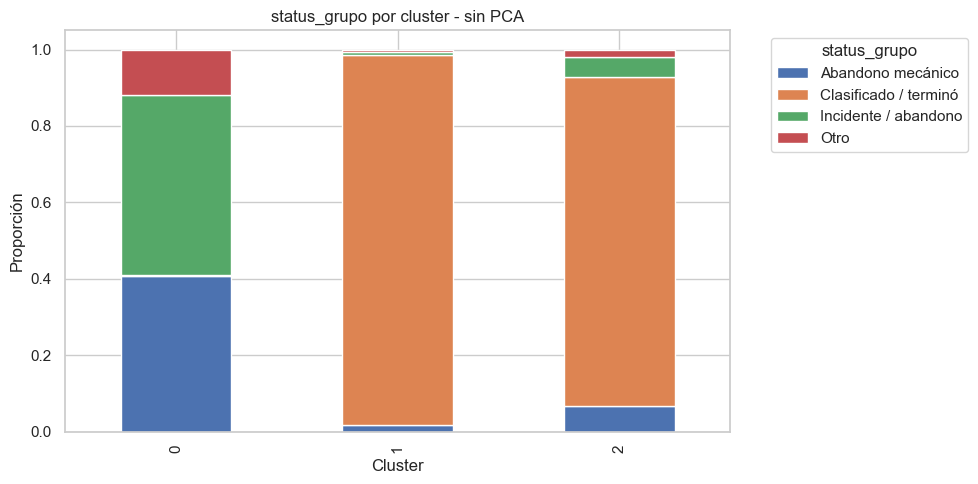


Distribución de decada por cluster sin PCA


decada,2000s,2010s,2020s
cluster_sin_pca,,,
0,0.463,0.395,0.141
1,0.347,0.416,0.236
2,0.319,0.461,0.220


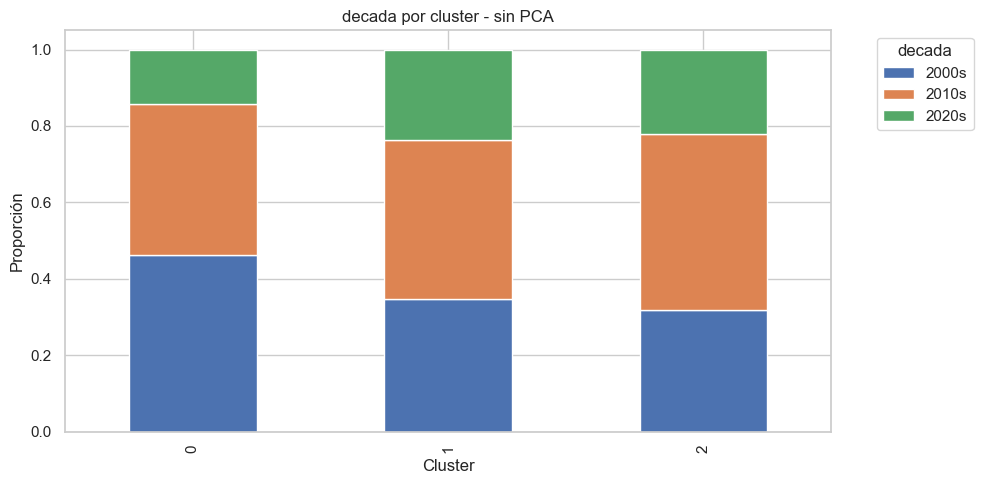

In [14]:
for var_cat in ["resultado_grupo", "largada_grupo", "status_grupo", "decada"]:
    if var_cat in df_cluster.columns:
        print("\n", "="*80)
        print(f"Distribución de {var_cat} por cluster sin PCA")
        tabla = perfil_categorico(df_cluster, "cluster_sin_pca", var_cat)
        display(tabla)
        tabla.to_csv(PROCESSED_DIR / f"formula1_cluster_sin_pca_{var_cat}.csv")

        plot_categorica_fill(
            df_cluster,
            cluster_col="cluster_sin_pca",
            variable_cat=var_cat,
            titulo=f"{var_cat} por cluster - sin PCA",
            guardar_como=f"cluster_sin_pca_{var_cat}.png"
        )

## 10. Clustering con PCA

Ahora se repite el análisis usando la matriz de scores de PCA. En este caso, cada observación ya está representada por pocas componentes principales.

Este enfoque puede ser útil porque:

- reduce redundancia entre variables originales;
- resume la información en ejes interpretables;
- puede estabilizar el clustering si las variables originales están correlacionadas.

Pero también puede perder información si se descartan componentes relevantes.

,k,inercia,silhouette,proporcion_cluster_mas_chico,gap,gap_menos_s
0,2,2906.8121,0.4392,0.4327,0.8896,0.8701
1,3,1694.8199,0.4853,0.1540,1.1255,1.1064
2,4,1191.0772,0.4326,0.1513,1.1442,1.1293
3,5,965.6400,0.4149,0.0567,1.0884,1.0725
4,6,807.2444,0.4047,0.0600,1.0396,1.0236
5,7,669.2374,0.3902,0.0300,1.0900,1.0766
6,8,583.8472,0.3968,0.0300,1.0970,1.0823
7,9,514.7421,0.3717,0.0287,1.1034,1.0867
8,10,463.2395,0.3687,0.0293,1.0963,1.0831


Resumen: {'k_silhouette_sugerido': 3, 'k_gap': 1, 'n_eval': 1500}


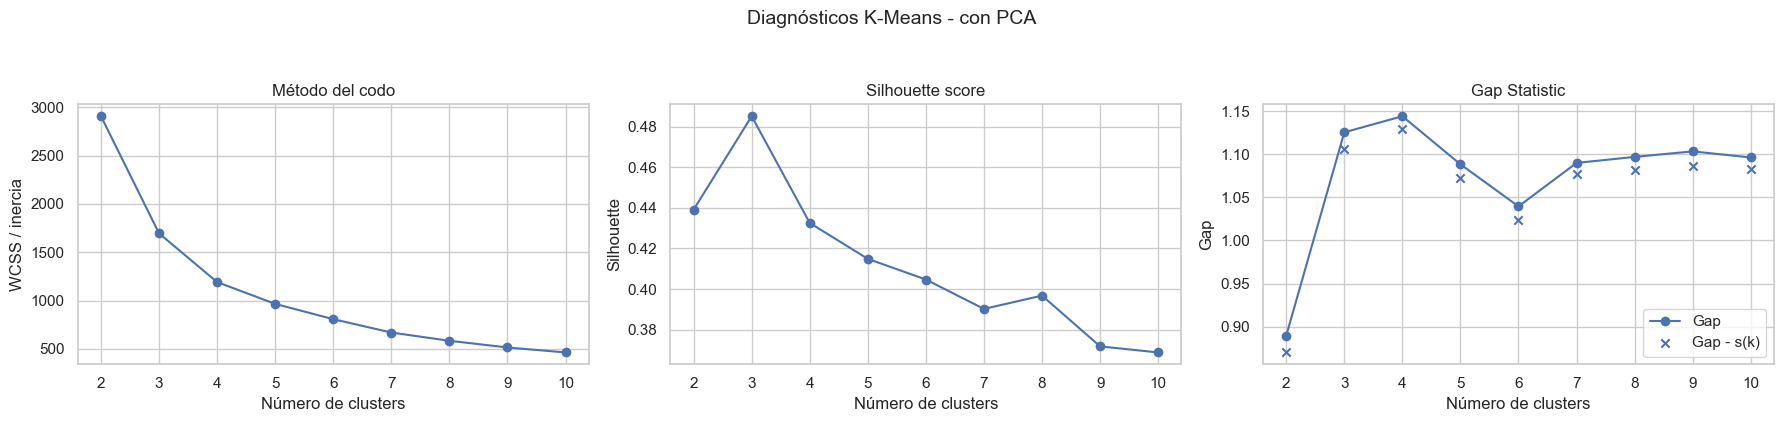

In [15]:
resultados_con_pca, resumen_con_pca = evaluar_kmeans(
    X_con_pca,
    k_min=2,
    k_max=10,
    sample_size=1500,
    random_state=RANDOM_STATE,
    n_references_gap=50
)

display(resultados_con_pca.round(4))
print("Resumen:", {k: v for k, v in resumen_con_pca.items() if k != "idx_eval"})

plot_diagnosticos_kmeans(
    resultados_con_pca,
    titulo="Diagnósticos K-Means - con PCA",
    guardar_como="cluster_con_pca_diagnosticos_kmeans.png"
)

In [16]:
# Ajustar si al mirar los gráficos se justifica otro valor.
K_FINAL_CON_PCA = 3

print("K final elegido para clustering con PCA:", K_FINAL_CON_PCA)

kmeans_con_pca, labels_con_pca = ajustar_kmeans_final(
    X_con_pca,
    k=K_FINAL_CON_PCA,
    nombre_cluster="cluster_con_pca",
    random_state=RANDOM_STATE
)

df_cluster["cluster_con_pca"] = labels_con_pca

K final elegido para clustering con PCA: 3
Tamaño de clusters para cluster_con_pca:


,n
0,1475
1,3625
2,4747


### 10.1. Clustering jerárquico con PCA, sobre muestra

Se repite el análisis jerárquico sobre la matriz PCA. Esto permite ver si la estructura jerárquica cambia al trabajar sobre las componentes principales.

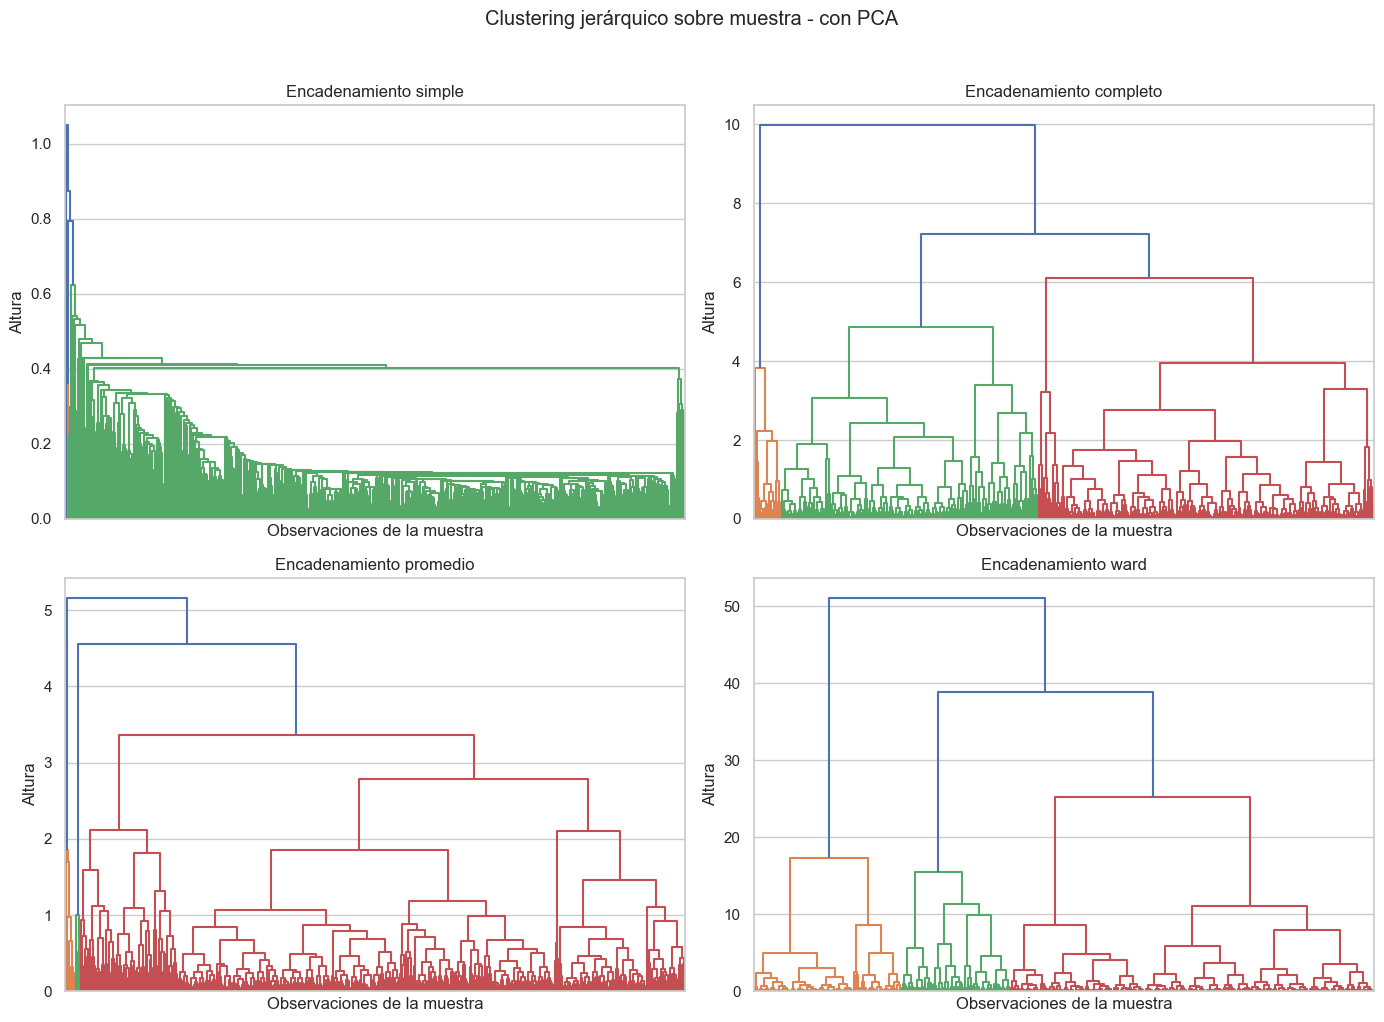

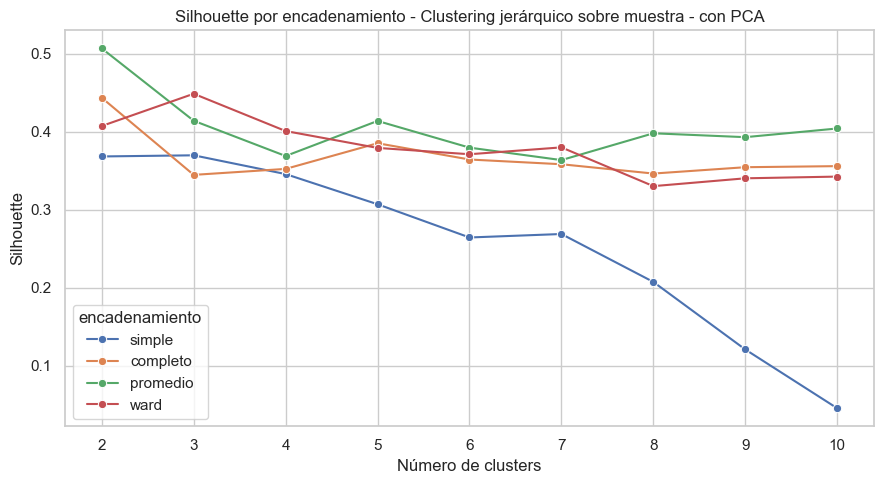

Tamaño de clusters Ward en muestra, k=3:


,n
0,469
1,191
2,140


Coeficientes cofenéticos:


,encadenamiento,coeficiente_cofenetico
2,promedio,0.7533
1,completo,0.6721
3,ward,0.6484
0,simple,0.5987


Silhouette por encadenamiento:


encadenamiento,completo,promedio,simple,ward
k,,,,
2,0.4437,0.5070,0.3685,0.4075
3,0.3449,0.4142,0.3699,0.4488
4,0.3525,0.3690,0.3459,0.4010
5,0.3854,0.4140,0.3072,0.3794
6,0.3646,0.3798,0.2646,0.3713
7,0.3585,0.3638,0.2691,0.3801
8,0.3466,0.3982,0.2076,0.3304
9,0.3547,0.3932,0.1211,0.3405
10,0.3561,0.4043,0.0457,0.3427


In [17]:
jerarquico_con_pca = analisis_jerarquico_muestra(
    X_con_pca,
    k_final=K_FINAL_CON_PCA,
    titulo="Clustering jerárquico sobre muestra - con PCA",
    sample_size=800,
    random_state=RANDOM_STATE,
    guardar_como="cluster_con_pca_dendrogramas_muestra.png"
)

print("Coeficientes cofenéticos:")
display(jerarquico_con_pca["cofenetico"].round(4))

print("Silhouette por encadenamiento:")
display(jerarquico_con_pca["silhouette"].pivot(index="k", columns="encadenamiento", values="silhouette").round(4))

## 11. Perfil de clusters con PCA

Aunque el algoritmo usa componentes principales, los clusters se interpretan nuevamente con las variables originales. Esto evita describir los grupos solo como “alto CP1” o “bajo CP2” y permite traducirlos al problema de Fórmula 1.

In [18]:
perfil_con_pca = perfil_numerico(df_cluster, "cluster_con_pca", variables_perfil_numericas)
display(perfil_con_pca)

perfil_con_pca.to_csv(PROCESSED_DIR / "formula1_cluster_perfil_numerico_con_pca.csv")

grid                               positionOrder                               laps_pct                              \
                count    mean median    std min max         count    mean median    std min max    count   mean median    std    min   
cluster_con_pca                                                                                                                        
0                1475  12.296   13.0  5.890   0  24          1475  19.407   20.0  2.235   7  24     1475  0.248  0.208  0.226  0.000   
1                3625   5.265    5.0  3.515   0  24          3625   5.042    4.0  3.554   1  22     3625  0.991  1.000  0.049  0.000   
2                4747  14.679   15.0  4.454   0  24          4747  12.874   13.0  3.809   2  24     4747  0.964  0.984  0.073  0.429   

                       driver_age                                        driver_championship_position                                   \
                   max      count    mean  median    std     min     max                        count    mean median    std  min   max   
cluster_con_pca                                                                                                                          
0                0.917       1475  28.606  28.041  5.089  17.760  43.817                         1475  13.450   14.0  5.927  1.0  27.0   
1                1.000       3625  29.450  29.109  4.858  18.623  43.893                         3625   5.055    5.0  3.091  1.0  17.0   
2                1.000       4747  27.265  26.231  4.905  17.454  43.874                         4747  15.119   15.0  4.489  1.0  27.0   

                driver_championship_wins                                 posiciones_ganadas                               
                                   count   mean median    std  min   max              count   mean median    std min max  
cluster_con_pca                                                                                                           
0                                   1475  0.174    0.0  0.664  0.0  11.0               1475 -7.112   -7.0  6.067 -24   8  
1                                   3625  1.251    0.0  2.264  0.0  19.0               3625  0.222    0.0  4.345 -20  21  
2                                   4747  0.011    0.0  0.110  0.0   2.0               4747  1.806    2.0  4.894 -20  19

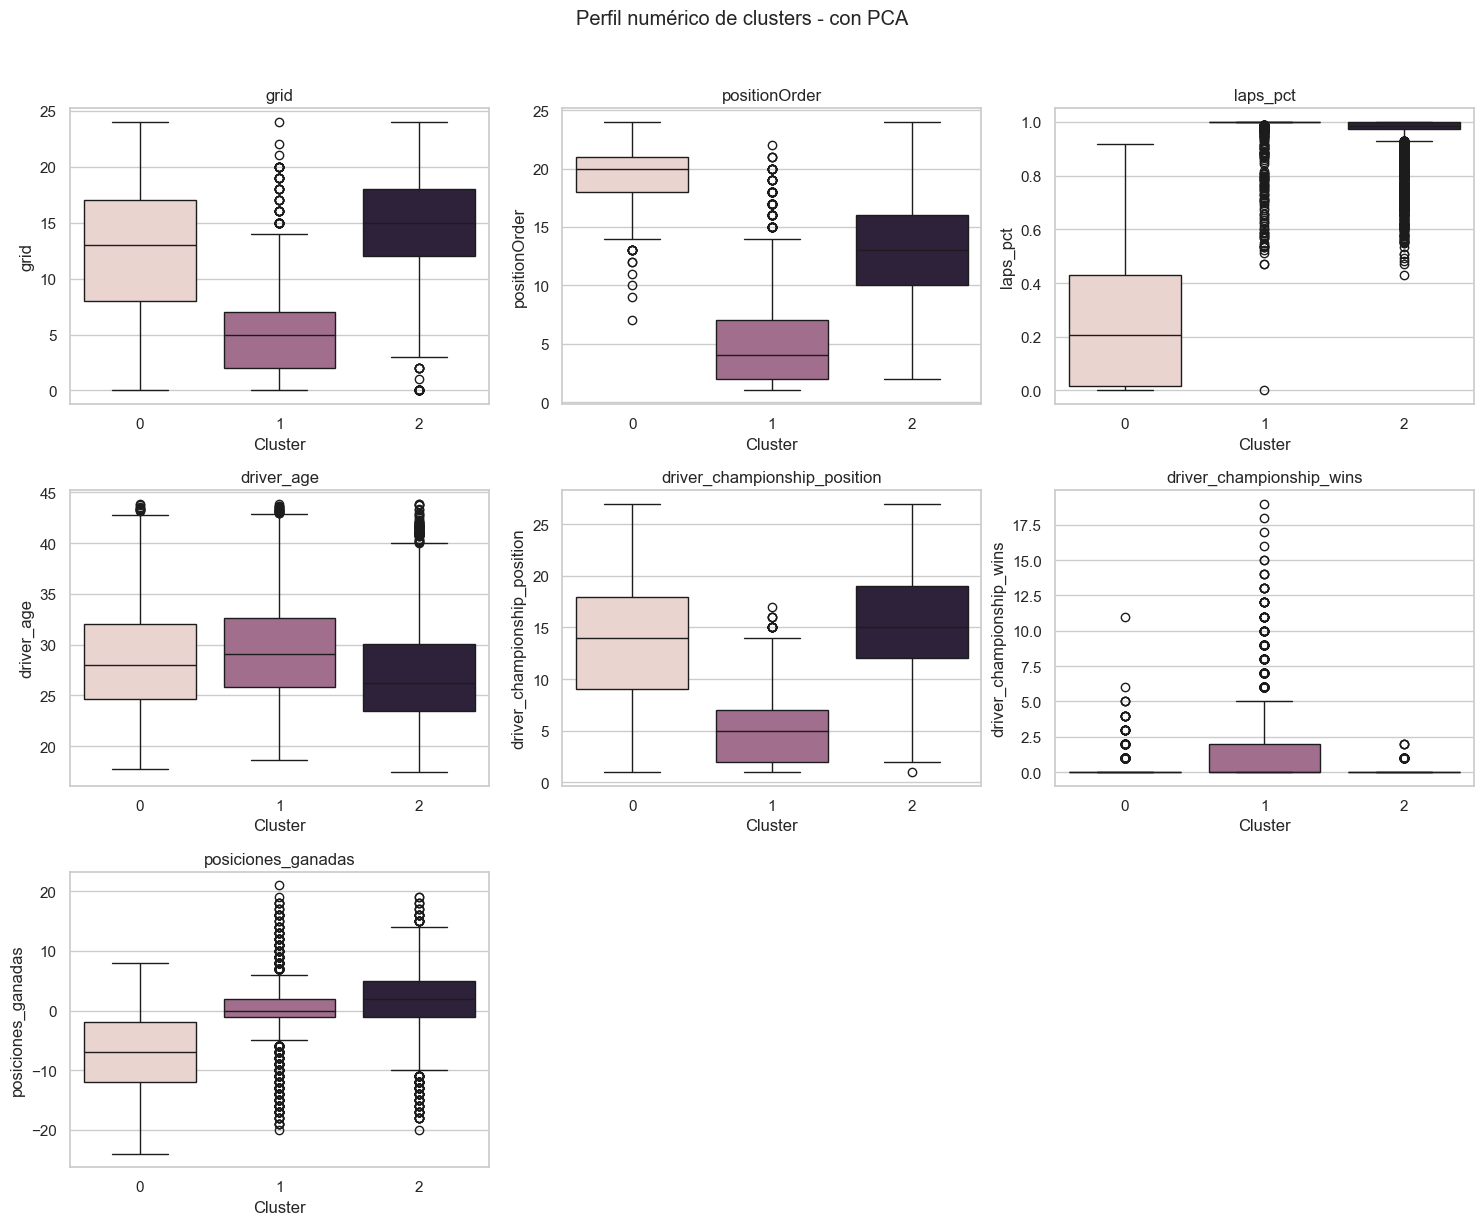

In [19]:
plot_boxplots_clusters(
    df_cluster,
    cluster_col="cluster_con_pca",
    variables=variables_perfil_numericas,
    titulo="Perfil numérico de clusters - con PCA",
    guardar_como="cluster_con_pca_boxplots.png"
)


Distribución de resultado_grupo por cluster con PCA


resultado_grupo,Fuera del top 10,Ganador,Podio,Top 10
cluster_con_pca,,,,
0,0.998,0.000,0.000,0.002
1,0.071,0.132,0.259,0.538
2,0.710,0.000,0.003,0.288


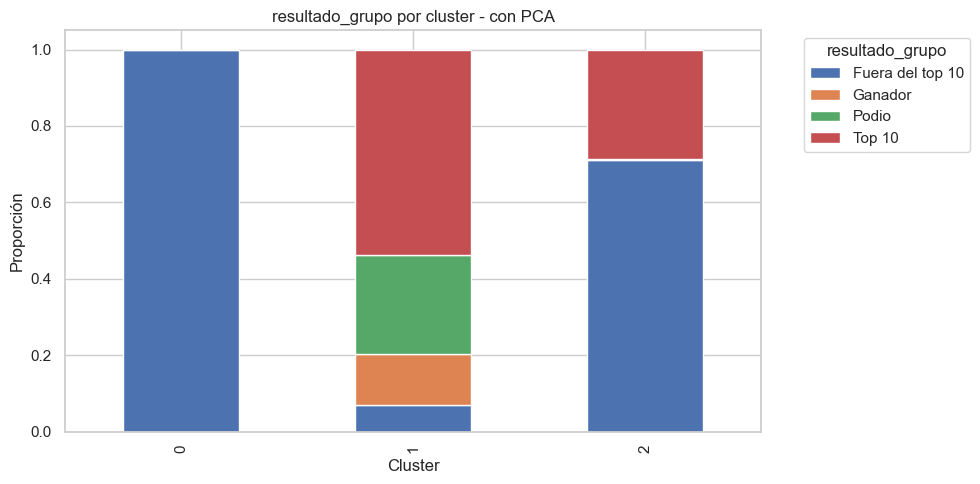


Distribución de largada_grupo por cluster con PCA


largada_grupo,Fondo,Pit lane / no largó,Pole,Top 10,Top 5
cluster_con_pca,,,,,
0,0.615,0.016,0.020,0.226,0.123
1,0.077,0.009,0.122,0.338,0.454
2,0.815,0.007,0.000,0.166,0.012


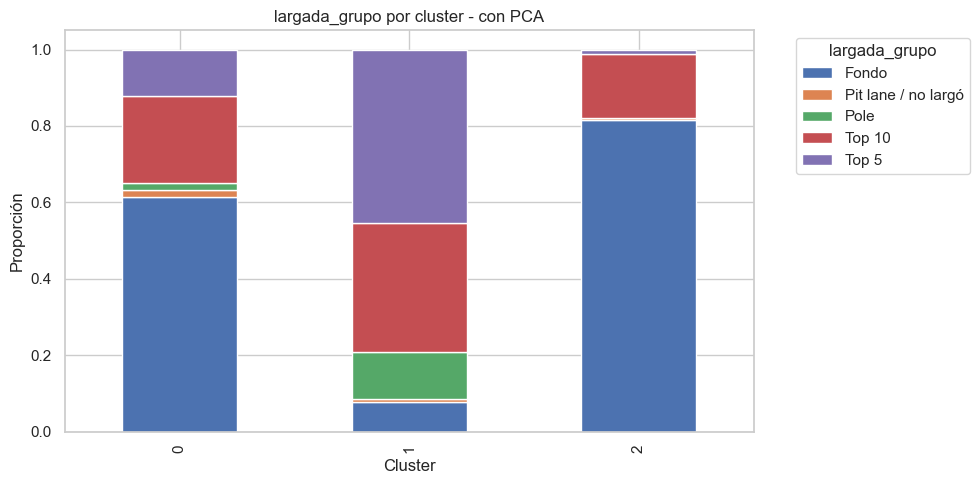


Distribución de status_grupo por cluster con PCA


status_grupo,Abandono mecánico,Clasificado / terminó,Incidente / abandono,Otro
cluster_con_pca,,,,
0,0.411,0.002,0.468,0.119
1,0.018,0.965,0.012,0.005
2,0.057,0.882,0.044,0.017


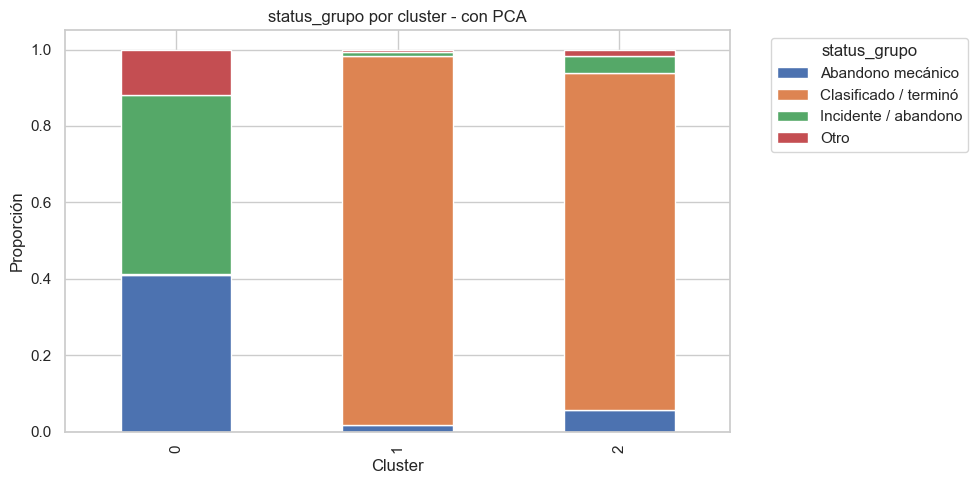


Distribución de decada por cluster con PCA


decada,2000s,2010s,2020s
cluster_con_pca,,,
0,0.465,0.398,0.137
1,0.348,0.414,0.237
2,0.320,0.457,0.224


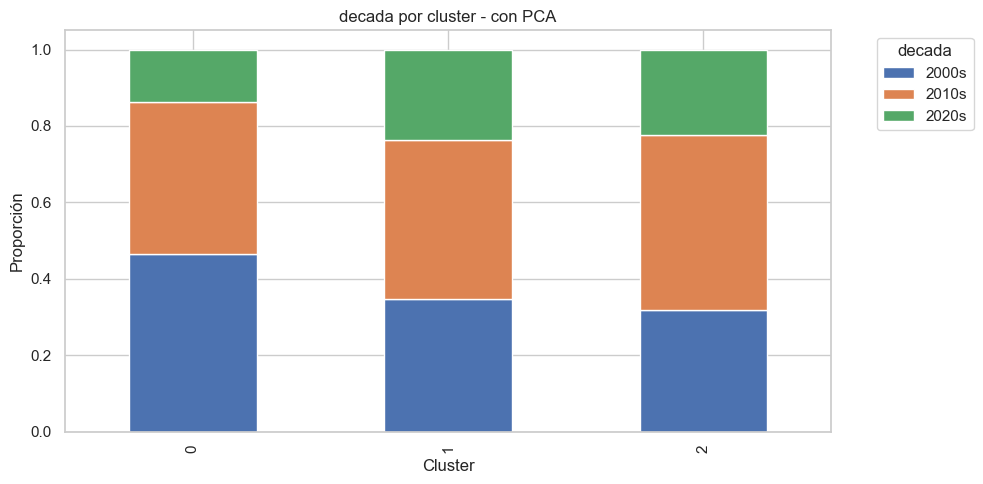

In [20]:
for var_cat in ["resultado_grupo", "largada_grupo", "status_grupo", "decada"]:
    if var_cat in df_cluster.columns:
        print("\n", "="*80)
        print(f"Distribución de {var_cat} por cluster con PCA")
        tabla = perfil_categorico(df_cluster, "cluster_con_pca", var_cat)
        display(tabla)
        tabla.to_csv(PROCESSED_DIR / f"formula1_cluster_con_pca_{var_cat}.csv")

        plot_categorica_fill(
            df_cluster,
            cluster_col="cluster_con_pca",
            variable_cat=var_cat,
            titulo=f"{var_cat} por cluster - con PCA",
            guardar_como=f"cluster_con_pca_{var_cat}.png"
        )

## 12. Variables suplementarias para interpretar clusters

En esta sección se analizan variables que no fueron utilizadas directamente para construir los clusters, pero que sirven para interpretar mejor los perfiles obtenidos. En particular, se estudian las escuderías (`constructor_name`) y los pilotos (`driver_name`) para observar si ciertos equipos o corredores aparecen con mayor frecuencia en alguno de los grupos.

Este análisis permite complementar la interpretación principal de los clusters. Por ejemplo, ayuda a identificar qué escuderías se asocian más al grupo de alto rendimiento, cuáles aparecen con mayor frecuencia en grupos de rendimiento medio-bajo y qué pilotos presentan mayor proporción de observaciones en el cluster de carreras problemáticas o abandonos.

Para evitar conclusiones sesgadas por pilotos o escuderías con muy pocas observaciones, se aplican filtros mínimos de cantidad de carreras antes de calcular proporciones.

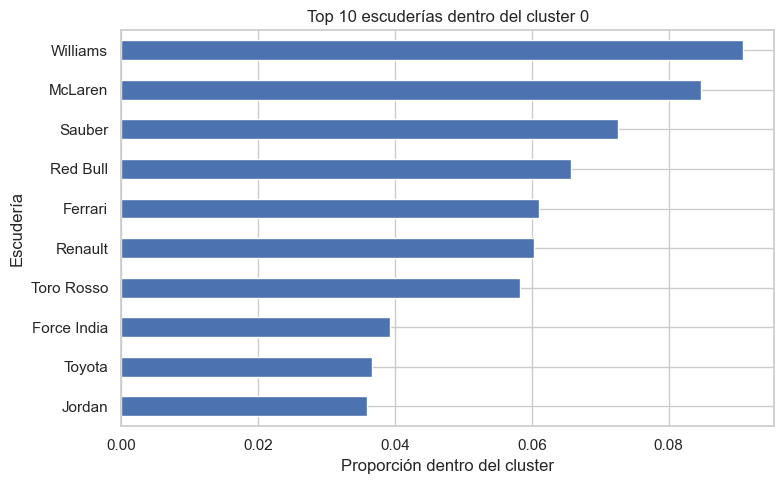

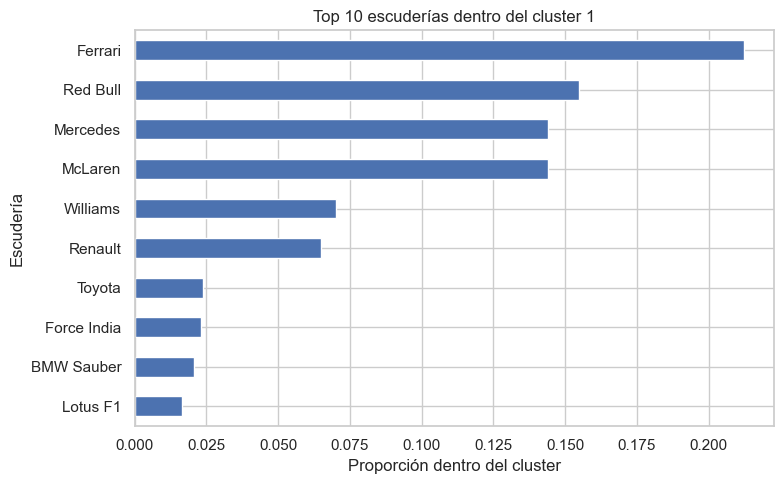

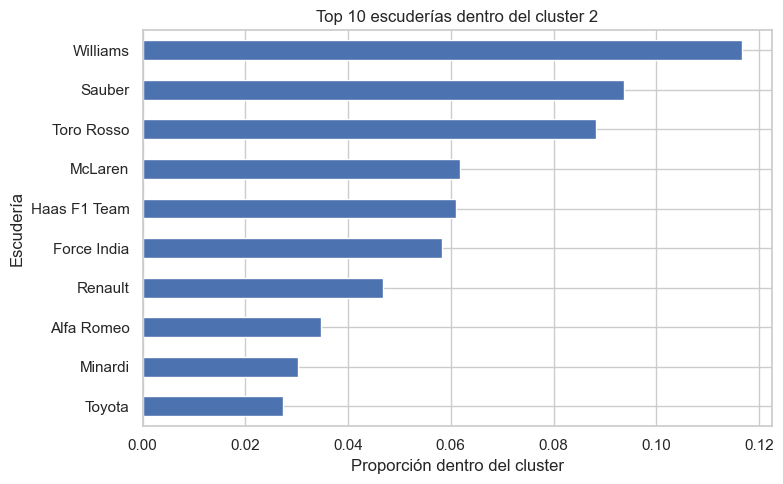

In [21]:
# ============================================================
# Escuderías más frecuentes dentro de cada cluster
# ============================================================

top_n = 10

for cluster in sorted(df_cluster["cluster_con_pca"].unique()):
    df_aux = df_cluster[df_cluster["cluster_con_pca"] == cluster]

    conteo_constructores = (
        df_aux["constructor_name"]
        .value_counts(normalize=True)
        .head(top_n)
        .sort_values()
    )

    plt.figure(figsize=(8, 5))
    conteo_constructores.plot(kind="barh")

    plt.title(f"Top {top_n} escuderías dentro del cluster {cluster}")
    plt.xlabel("Proporción dentro del cluster")
    plt.ylabel("Escudería")
    plt.tight_layout()
    plt.show()

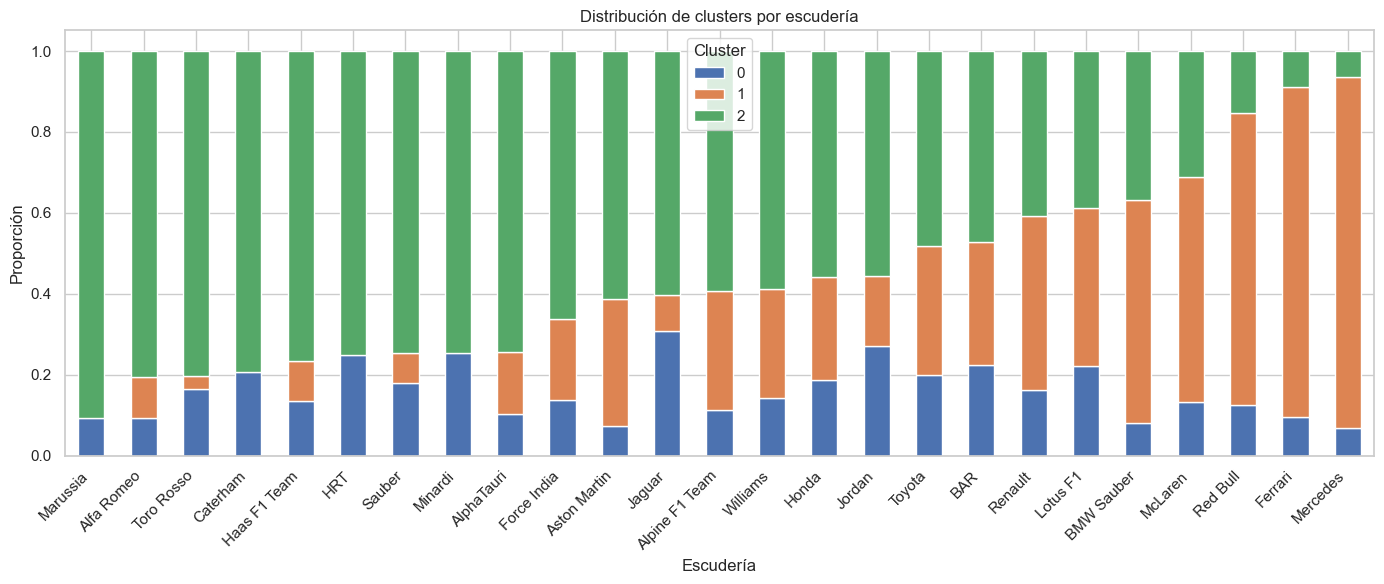

cluster_con_pca,0,1,2
constructor_name,,,
Marussia,0.093,0.000,0.907
Alfa Romeo,0.093,0.102,0.805
Toro Rosso,0.165,0.031,0.804
Caterham,0.207,0.000,0.793
Haas F1 Team,0.135,0.098,0.767
HRT,0.248,0.000,0.752
Sauber,0.180,0.074,0.747
Minardi,0.254,0.000,0.746
AlphaTauri,0.103,0.152,0.745


In [22]:
# ============================================================
# Distribución de clusters por escudería
# ============================================================

min_observaciones = 80

constructores_validos = (
    df_cluster["constructor_name"]
    .value_counts()
    .loc[lambda x: x >= min_observaciones]
    .index
)

df_constructores = df_cluster[
    df_cluster["constructor_name"].isin(constructores_validos)
].copy()

tabla_constructor_cluster = pd.crosstab(
    df_constructores["constructor_name"],
    df_constructores["cluster_con_pca"],
    normalize="index"
).round(3)

# Ordenamos por proporción en el cluster de alto rendimiento
# Cambiar el 2 si tu cluster de alto rendimiento tiene otro número.
tabla_constructor_cluster = tabla_constructor_cluster.sort_values(
    by=2,
    ascending=False
)

tabla_constructor_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Distribución de clusters por escudería")
plt.xlabel("Escudería")
plt.ylabel("Proporción")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

display(tabla_constructor_cluster)

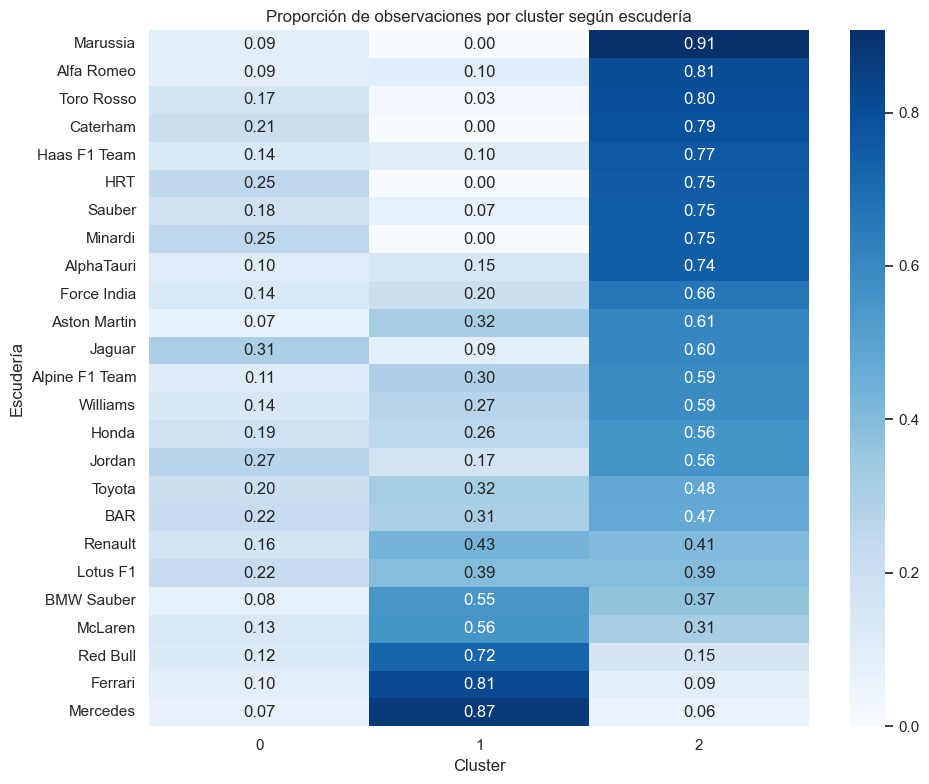

In [23]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    tabla_constructor_cluster,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Proporción de observaciones por cluster según escudería")
plt.xlabel("Cluster")
plt.ylabel("Escudería")
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# Distribución de clusters por piloto
# ============================================================

min_carreras_piloto = 30

pilotos_validos = (
    df_cluster["driver_name"]
    .value_counts()
    .loc[lambda x: x >= min_carreras_piloto]
    .index
)

df_pilotos = df_cluster[
    df_cluster["driver_name"].isin(pilotos_validos)
].copy()

tabla_piloto_cluster = pd.crosstab(
    df_pilotos["driver_name"],
    df_pilotos["cluster_con_pca"],
    normalize="index"
).round(3)

# Ordenamos por el cluster de carreras problemáticas / abandonos.
# Cambiar el 0 si tu cluster problemático tiene otro número.
tabla_piloto_cluster = tabla_piloto_cluster.sort_values(
    by=0,
    ascending=False
)

display(tabla_piloto_cluster.head(20))

cluster_con_pca,0,1,2
driver_name,,,
Heinz-Harald Frentzen,0.407,0.322,0.271
Eddie Irvine,0.396,0.208,0.396
Pedro de la Rosa,0.345,0.057,0.598
Jos Verstappen,0.340,0.000,0.660
Jean Alesi,0.300,0.000,0.700
Olivier Panis,0.298,0.175,0.526
Narain Karthikeyan,0.277,0.000,0.723
Jolyon Palmer,0.270,0.000,0.730
Kamui Kobayashi,0.267,0.053,0.680


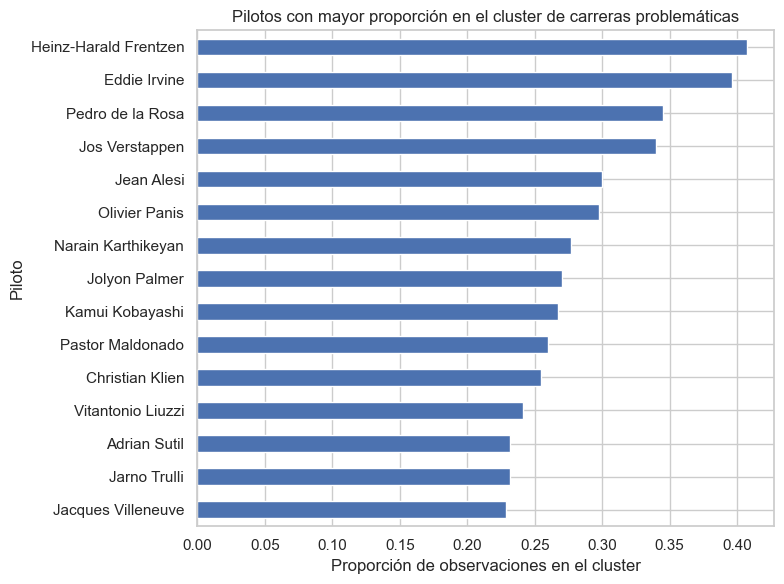

In [25]:
# ============================================================
# Pilotos más asociados al cluster 0: carreras problemáticas
# ============================================================

cluster_problematico = 0

top_pilotos_problematicos = (
    tabla_piloto_cluster[cluster_problematico]
    .head(15)
    .sort_values()
)

plt.figure(figsize=(8, 6))

top_pilotos_problematicos.plot(kind="barh")

plt.title("Pilotos con mayor proporción en el cluster de carreras problemáticas")
plt.xlabel("Proporción de observaciones en el cluster")
plt.ylabel("Piloto")
plt.tight_layout()
plt.show()

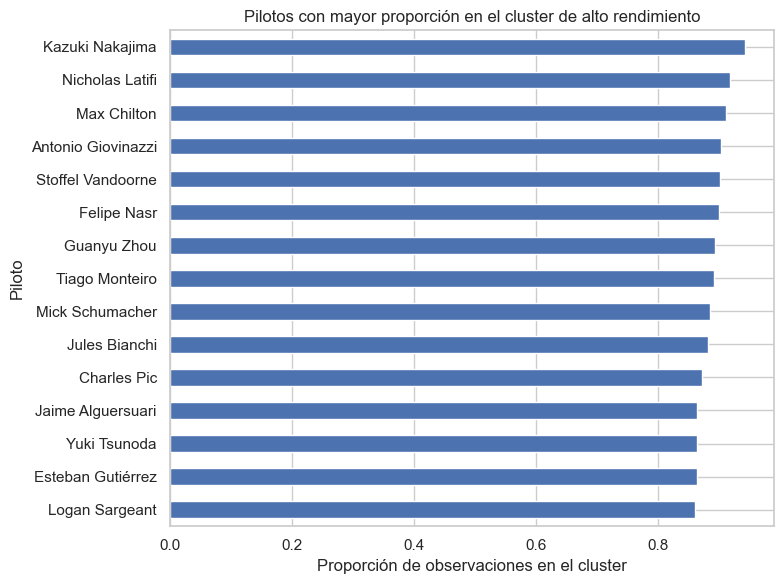

In [ ]:
# ============================================================
# Pilotos más asociados al cluster 2: alto rendimiento
# ============================================================

cluster_alto_rendimiento = 2

top_pilotos_alto_rendimiento = (
    tabla_piloto_cluster[cluster_alto_rendimiento]
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(8, 6))

top_pilotos_alto_rendimiento.plot(kind="barh")

plt.title("Pilotos con mayor proporción en el cluster de alto rendimiento")
plt.xlabel("Proporción de observaciones en el cluster")
plt.ylabel("Piloto")
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# Tasa de abandono por piloto
# ============================================================

df_cluster["abandono"] = df_cluster["status_grupo"].isin([
    "Abandono mecánico",
    "Incidente / abandono"
])

resumen_pilotos = (
    df_cluster
    .groupby("driver_name")
    .agg(
        carreras=("driver_name", "count"),
        tasa_abandono=("abandono", "mean"),
        tasa_cluster_problematico=("cluster_con_pca", lambda x: (x == cluster_problematico).mean()),
        tasa_alto_rendimiento=("cluster_con_pca", lambda x: (x == cluster_alto_rendimiento).mean())
    )
    .query("carreras >= @min_carreras_piloto")
    .sort_values("tasa_abandono", ascending=False)
    .round(3)
)

display(resumen_pilotos.head(20))

,carreras,tasa_abandono,tasa_cluster_problematico,tasa_alto_rendimiento
driver_name,,,,
Eddie Irvine,48,0.417,0.396,0.396
Heinz-Harald Frentzen,59,0.407,0.407,0.271
Jos Verstappen,47,0.404,0.340,0.660
Jean Alesi,30,0.367,0.300,0.700
Takuma Sato,89,0.348,0.202,0.674
Pedro de la Rosa,87,0.345,0.345,0.598
Vitantonio Liuzzi,79,0.329,0.241,0.747
Olivier Panis,57,0.316,0.298,0.526
Pastor Maldonado,96,0.312,0.260,0.708


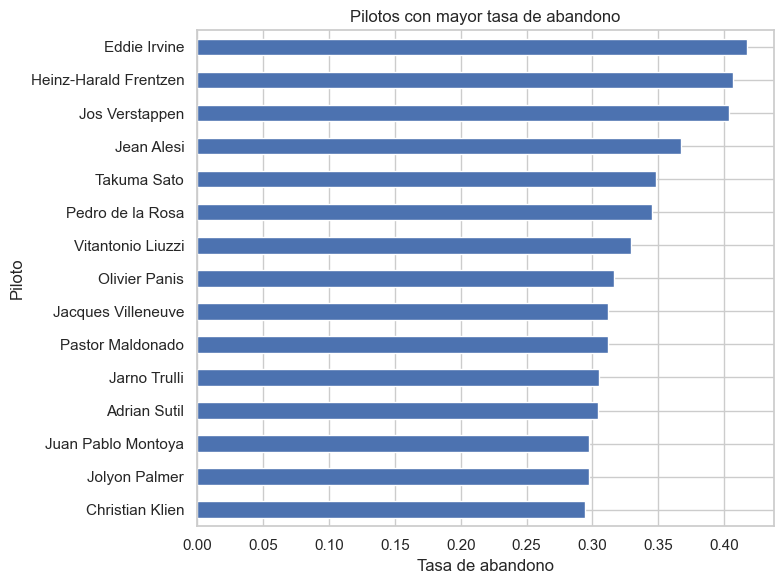

In [28]:
top_abandono = (
    resumen_pilotos
    .head(15)["tasa_abandono"]
    .sort_values()
)

plt.figure(figsize=(8, 6))

top_abandono.plot(kind="barh")

plt.title("Pilotos con mayor tasa de abandono")
plt.xlabel("Tasa de abandono")
plt.ylabel("Piloto")
plt.tight_layout()
plt.show()

## 13. Comparación entre clustering sin PCA y con PCA

Ahora se compara si ambas estrategias producen grupos parecidos.

Se usan dos herramientas:

1. **Tabla cruzada:** muestra cómo se reparten las observaciones entre los clusters de ambos métodos.
2. **Adjusted Rand Index (ARI):** mide el acuerdo entre particiones, corrigiendo por azar. Toma valores cercanos a 1 cuando las particiones son muy similares y valores cercanos a 0 cuando el acuerdo no supera mucho al azar.

In [29]:
comparacion_clusters = pd.crosstab(
    df_cluster["cluster_sin_pca"],
    df_cluster["cluster_con_pca"],
    rownames=["Sin PCA"],
    colnames=["Con PCA"]
)

comparacion_clusters_norm = pd.crosstab(
    df_cluster["cluster_sin_pca"],
    df_cluster["cluster_con_pca"],
    normalize="index"
).round(3)

ari = adjusted_rand_score(df_cluster["cluster_sin_pca"], df_cluster["cluster_con_pca"])

print("Tabla cruzada - cantidades")
display(comparacion_clusters)

print("Tabla cruzada - proporciones por cluster sin PCA")
display(comparacion_clusters_norm)

print(f"Adjusted Rand Index: {ari:.4f}")

comparacion_clusters.to_csv(PROCESSED_DIR / "formula1_cluster_comparacion_sin_pca_vs_con_pca.csv")
comparacion_clusters_norm.to_csv(PROCESSED_DIR / "formula1_cluster_comparacion_sin_pca_vs_con_pca_normalizada.csv")

Tabla cruzada - cantidades


Con PCA,0,1,2
Sin PCA,,,
0,1387,17,38
1,2,3601,551
2,86,7,4158


Tabla cruzada - proporciones por cluster sin PCA


cluster_con_pca,0,1,2
cluster_sin_pca,,,
0,0.962,0.012,0.026
1,0.000,0.867,0.133
2,0.020,0.002,0.978


Adjusted Rand Index: 0.7769


## 14. Visualización en el plano PCA

Para comparar visualmente ambos enfoques, se grafican las observaciones en el plano CP1-CP2 y se colorean según los clusters obtenidos.

Aunque el clustering sin PCA no se calculó en el espacio PCA, proyectarlo en este plano ayuda a comparar visualmente las particiones.

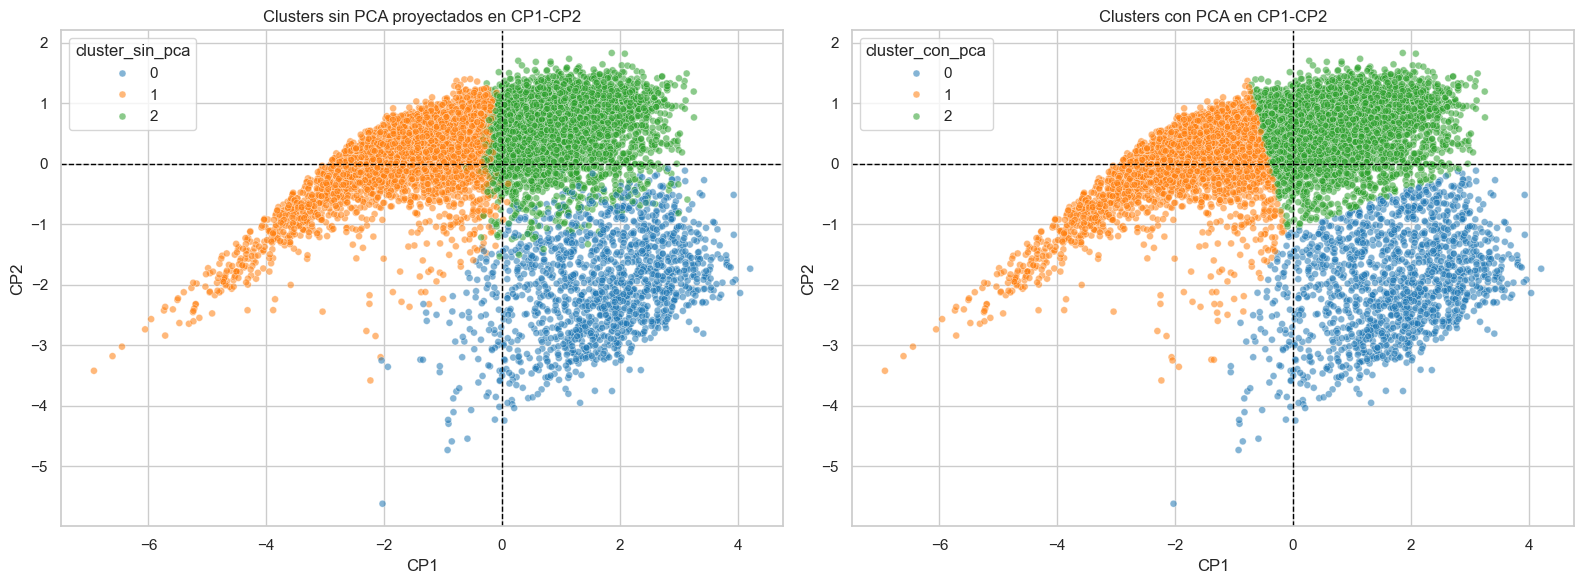

In [30]:
if X_con_pca_df.shape[1] >= 2:
    df_plot_pca = pd.concat(
        [df_cluster.reset_index(drop=True), X_con_pca_df.reset_index(drop=True)],
        axis=1
    )

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(
        data=df_plot_pca,
        x="CP1", y="CP2",
        hue="cluster_sin_pca",
        palette="tab10",
        alpha=0.55,
        s=25,
        ax=axs[0]
    )
    axs[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axs[0].axvline(0, color="black", linestyle="--", linewidth=1)
    axs[0].set_title("Clusters sin PCA proyectados en CP1-CP2")

    sns.scatterplot(
        data=df_plot_pca,
        x="CP1", y="CP2",
        hue="cluster_con_pca",
        palette="tab10",
        alpha=0.55,
        s=25,
        ax=axs[1]
    )
    axs[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axs[1].axvline(0, color="black", linestyle="--", linewidth=1)
    axs[1].set_title("Clusters con PCA en CP1-CP2")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "cluster_comparacion_en_plano_pca.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("La matriz PCA tiene menos de dos componentes. No se puede graficar CP1 vs CP2.")

## 15. Guardar resultados finales

Se guardan las bases con las etiquetas de cluster para poder usarlas en el informe y en análisis posteriores.

In [31]:
# Base completa de clustering con ambas etiquetas.
ruta_resultados = PROCESSED_DIR / "formula1_cluster_resultados.csv"
df_cluster.to_csv(ruta_resultados, index=False)

# Versiones separadas por enfoque.
cols_id = [c for c in ["resultId", "raceId", "driverId", "constructorId", "year", "driver_name", "constructor_name", "race_name"] if c in df_cluster.columns]

cols_sin_pca = cols_id + variables_cluster_base + ["posiciones_ganadas", "cluster_sin_pca"]
cols_con_pca = cols_id + variables_cluster_base + ["posiciones_ganadas", "cluster_con_pca"]

df_cluster[cols_sin_pca].to_csv(PROCESSED_DIR / "formula1_cluster_sin_pca_resultados.csv", index=False)
df_cluster[cols_con_pca].to_csv(PROCESSED_DIR / "formula1_cluster_con_pca_resultados.csv", index=False)

# Variables utilizadas.
pd.DataFrame({"variable": variables_cluster_base}).to_csv(
    PROCESSED_DIR / "formula1_cluster_variables_activas.csv", index=False
)

print("Archivos guardados:")
print("-", ruta_resultados)
print("-", PROCESSED_DIR / "formula1_cluster_sin_pca_resultados.csv")
print("-", PROCESSED_DIR / "formula1_cluster_con_pca_resultados.csv")
print("-", PROCESSED_DIR / "formula1_cluster_variables_activas.csv")

Archivos guardados:
- /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_cluster_resultados.csv
- /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_cluster_sin_pca_resultados.csv
- /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_cluster_con_pca_resultados.csv
- /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_cluster_variables_activas.csv


# 16. Interpretación para el informe

En esta etapa se realizó el análisis cluster con el objetivo de identificar perfiles de observaciones similares dentro del dataset de Fórmula 1. Si bien inicialmente se exploró una alternativa de clustering sin PCA, esta se utilizó únicamente como análisis exploratorio. Para la interpretación final se priorizó el clustering realizado sobre la matriz de componentes principales, ya que permite trabajar con una representación más resumida de la información y evita redundancias entre variables correlacionadas.

## Clustering con PCA

Para el clustering con PCA se utilizaron las dos primeras componentes principales, **CP1** y **CP2**. Esta elección se basó en la regla de Kaiser, que sugiere conservar las componentes con autovalor mayor a 1. En este caso, las dos primeras componentes cumplen ese criterio y explican aproximadamente el 65% de la variabilidad total.

Si bien la inclusión de CP3 permitía alcanzar aproximadamente el 80% de varianza acumulada, esa componente quedó asociada principalmente a `driver_age`. Como el objetivo del clustering era segmentar perfiles de desempeño en carrera, se decidió no incorporarla a la matriz final.

Las componentes utilizadas pueden interpretarse de la siguiente manera:

- **CP1:** desempeño posicional general. Valores positivos se asocian con peores posiciones de largada, llegada y campeonato, mientras que valores negativos se vinculan con mejores posiciones, mayor proporción de carrera completada y mayor cantidad de victorias en el campeonato.
- **CP2:** continuidad en carrera o proporción de vueltas completadas. Está dominada por `laps_pct`, variable que mide qué proporción de la carrera completó cada piloto.

Se decidió excluir `circuit_alt` del conjunto activo porque generaba un grupo asociado principalmente a la altitud del circuito, lo cual desviaba la interpretación hacia una dimensión contextual y no estrictamente deportiva. También se reemplazó `laps` por `laps_pct`, ya que las carreras no tienen todas la misma cantidad de vueltas y, por lo tanto, el número bruto de vueltas no es directamente comparable entre carreras.

## Selección del número de clusters

A partir de los diagnósticos de K-Means, se decidió trabajar con **K = 3**. Esta elección se justifica porque el índice silhouette alcanza su mejor valor para tres clusters y, además, la solución resulta más interpretable que alternativas con mayor cantidad de grupos. En particular, la solución con cuatro clusters generaba un grupo intermedio sin un perfil claramente diferenciado, por lo que se priorizó una segmentación más simple y estable.

La solución final con tres clusters permite distinguir tres perfiles principales:

## Perfil de los clusters

### Cluster 0: carreras problemáticas o abandonos

El cluster 0 agrupa observaciones asociadas a carreras con bajo desarrollo competitivo para el piloto. Se caracteriza por una baja proporción de vueltas completadas (`laps_pct`), posiciones finales desfavorables y una alta presencia de abandonos mecánicos o incidentes.

Aunque algunos pilotos de este grupo no necesariamente largan desde las peores posiciones, el desarrollo de la carrera tiende a ser negativo. Esto se observa en la baja proporción de carrera completada, en la mayor frecuencia de abandonos y en la pérdida de posiciones durante la carrera.

En términos generales, este cluster representa **carreras problemáticas, abandonos o desempeños muy desfavorables**.

### Cluster 1: pilotos que completan la carrera con rendimiento medio-bajo

El cluster 1 reúne observaciones de pilotos que suelen completar la carrera, pero que mayormente finalizan fuera de las posiciones principales. Este grupo presenta valores altos de `laps_pct`, lo que indica que los pilotos generalmente terminan o completan una alta proporción de la carrera.

Sin embargo, también se observa que suelen largar desde posiciones retrasadas, principalmente desde el fondo, y que la mayoría de los resultados se ubican fuera del top 10. A diferencia del cluster 0, el problema principal no parece ser el abandono, sino un rendimiento competitivo limitado.

Por lo tanto, este cluster puede interpretarse como **pilotos finalizadores de rendimiento medio-bajo**.

### Cluster 2: alto rendimiento competitivo

El cluster 2 representa el grupo de mejor desempeño deportivo. Se caracteriza por mejores posiciones de largada (`grid` bajo), mejores posiciones finales (`positionOrder` bajo), mejor ubicación en el campeonato y mayor presencia de victorias acumuladas.

Además, este grupo concentra una mayor proporción de resultados en top 10, podios y victorias. También presenta una alta proporción de carreras completadas, lo que indica que los buenos resultados no se deben únicamente a la posición de largada, sino también a una mayor consistencia durante la carrera.

En síntesis, este cluster representa **observaciones de alto rendimiento competitivo**, asociadas a pilotos que largan adelante, terminan en buenas posiciones y tienen mejor desempeño en el campeonato.

## Decisión final recomendada

La solución final elegida es el **clustering con PCA y K = 3**, ya que permite obtener grupos interpretables en términos del problema. Los clusters resultantes no solo se separan visualmente en el plano CP1-CP2, sino que también presentan diferencias claras en variables relevantes como posición de largada, posición final, proporción de carrera completada, estado final de la carrera y resultado agrupado.

En términos generales, los tres grupos obtenidos resumen tres perfiles deportivos:

1. **Carreras problemáticas o abandonos.**
2. **Finalizadores de rendimiento medio-bajo.**
3. **Pilotos/carreras de alto rendimiento competitivo.**

Esta segmentación permite transformar la información numérica original en una nueva variable categórica útil para describir perfiles de carrera dentro del dataset.